## Th1/Th2 validation summary plots

Paper figure pipeline

Goal: a single heatmap where rows are perturbations and columns are quantifications.
Columns come from two blocks:
1. **Bulk RNA-seq** (placeholder for now) — Section 1
2. **Flow cytometry** — Section 2: log2 fold change vs mean(NTC) per donor, two-sided one-sample t-test of log2FC vs 0, BH-adjusted within each (condition, measurement) column.
3. **Heatmap** — Section 3: plotting from any summary dataframe matching the shared schema.

Section 1 and Section 2 each emit a long-format summary dataframe with columns
`[perturbation, condition, measurement, n, mean_log2FC, p_value, adj_p_value]`,
and Section 3 concatenates / filters / plots them.

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# Keep text editable in Illustrator: embed TrueType (Type 42) in PDF/PS
# and leave SVG text as <text> rather than converting to paths.
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
def bh_adjust_within(df, group_cols=('condition', 'measurement'),
                     p_col='p_value', out_col='adj_p_value'):
    """Add a column of BH-adjusted p-values, computed independently within
    each `group_cols` group. Rows with NaN p-values stay NaN."""
    df = df.copy()
    df[out_col] = np.nan
    for _, idx in df.groupby(list(group_cols)).groups.items():
        sub = df.loc[idx, p_col]
        mask = sub.notna()
        if mask.sum() == 0:
            continue
        adj = multipletests(sub[mask].values, method='fdr_bh')[1]
        df.loc[sub[mask].index, out_col] = adj
    return df

## 1. Bulk RNA-seq signature effects

For each (perturbation × condition), summarise the bulk DE effect on the
**Ota Th2-vs-Th1** in-vivo signature. The signature gene set is the
intersection of significant genes (`adj_p_value < 0.01`) in the **Ota** and
**Hollbacker** cohorts; we take the top-50 (Th2-direction) and bottom-50
(Th1-direction) by Ota z-score, producing two columns: `bulk_Th2` and
`bulk_Th1`.

For each (target, condition, direction):
- `mean_log2FC` is the mean DESeq2 `log_fc` on the direction's signature
  genes (named `mean_log2FC` for schema compatibility with the FACS section).
- `mean_zscore` is the mean per-gene `zscore`, used to colour the bulk
  heatmap panels.
- `p_value` is a two-sided one-sample t-test of the per-gene `zscore` vs 0.
- `adj_p_value` is BH-adjusted within each `(condition, measurement)` column.


In [3]:
def summarize_signature_effect(de_df, sig_up_genes, sig_down_genes,
                               effect_col='log_fc', test_col='zscore',
                               target_col='target_contrast_gene_name',
                               gene_col='gene_name',
                               correction_group=('condition', 'measurement')):
    """For each (target, condition) and each signature direction, summarise the
    bulk DE effect on those genes.

    `sig_up_genes` = top-N Th2-direction genes (most-positive Ota zscore).
    `sig_down_genes` = top-N Th1-direction genes (most-negative Ota zscore).

    Output measurements: 'bulk_Th2' and 'bulk_Th1'.

    Schema: [perturbation, condition, measurement, n, mean_log2FC, mean_zscore,
    sem_zscore, p_value, adj_p_value].
      - `mean_log2FC` = mean DESeq2 log_fc on the signature genes.
      - `mean_zscore` = mean per-gene zscore on the signature genes
        (heatmap colour for bulk panels).
      - `sem_zscore`  = standard error of the per-gene zscore mean
        (std(ddof=1) / sqrt(n)); used as error bars in the forest plot.
      - `p_value`     = two-sided one-sample t-test of `test_col` vs 0.
    """
    rows = []
    for direction, sig in [('Th2', sig_up_genes), ('Th1', sig_down_genes)]:
        measurement = f'bulk_{direction}'
        sub = de_df[de_df[gene_col].isin(sig)]
        for (target, cond), grp in sub.groupby([target_col, 'condition']):
            vals_test = grp[test_col].dropna().values
            vals_eff = grp[effect_col].dropna().values
            n = len(vals_test)
            mean_eff = vals_eff.mean() if len(vals_eff) else np.nan
            mean_z = vals_test.mean() if n else np.nan
            sem_z = vals_test.std(ddof=1) / np.sqrt(n) if n >= 2 else np.nan
            p = stats.ttest_1samp(vals_test, 0).pvalue if n >= 2 else np.nan
            rows.append({'perturbation': target, 'condition': cond,
                         'measurement': measurement,
                         'n': n,
                         'mean_log2FC': mean_eff,
                         'mean_zscore': mean_z,
                         'sem_zscore': sem_z,
                         'p_value': p})
    summary = pd.DataFrame(rows)
    if correction_group is not None and len(summary):
        summary = bh_adjust_within(summary, group_cols=correction_group)
    return summary


In [4]:
# Load combined bulk DE results (written by bulkRNAseq_analysis.ipynb).
combined_de = pd.read_csv('results/bulkRNAseq_DESeq2_results.combined_v2.csv')

# Load Ota and Hollbacker Th2-vs-Th1 in-vivo signatures and intersect at adj_p_value < 0.01
ota_signature = pd.read_csv('results/Ota_Th2vsTh1_DE_results.csv', index_col='variable').dropna()
hollbacker_signature = pd.read_csv('results/hollbacher_Th2vsTh1_DE_results.csv', index_col='variable').dropna()
sig_genes_both = list(
    set(ota_signature.index[ota_signature['adj_p_value'] < 0.01])
    & set(hollbacker_signature.index[hollbacker_signature['adj_p_value'] < 0.01])
)
sig_in_both = ota_signature.loc[sig_genes_both]

# Top/bottom 50 by Ota z-score: one Th2 bucket + one Th1 bucket.
n_top = 50
sig_up = sig_in_both.nlargest(n_top, 'zscore').index.tolist()    # Th2 direction
sig_down = sig_in_both.nsmallest(n_top, 'zscore').index.tolist() # Th1 direction
print(f'Signature: {len(sig_up)} Th2-direction + {len(sig_down)} Th1-direction genes '
      f'(Ota∩Hollbacker, adj_p<0.01, top/bottom {n_top} by Ota zscore)')

bulk_summary = summarize_signature_effect(
    combined_de, sig_up_genes=sig_up, sig_down_genes=sig_down,
)
print(f'bulk_summary: {bulk_summary.shape}')
display(bulk_summary.head())

Signature: 50 Th2-direction + 50 Th1-direction genes (Ota∩Hollbacker, adj_p<0.01, top/bottom 50 by Ota zscore)
bulk_summary: (86, 9)


,perturbation,condition,measurement,n,mean_log2FC,mean_zscore,sem_zscore,p_value,adj_p_value
0,APPBP2,Th0,bulk_Th2,50,0.132628,0.435366,0.239343,0.075025,0.126473
1,CDKAL1,Th0,bulk_Th2,50,0.141308,0.425597,0.173117,0.017536,0.066637
2,FAM120A,Th0,bulk_Th2,50,0.179605,0.653995,0.228426,0.006158,0.039001
3,FBXO32,Th0,bulk_Th2,50,0.030049,0.365748,0.139041,0.011363,0.053975
4,FBXO32-3,Th0,bulk_Th2,50,0.116194,0.323323,0.175097,0.070858,0.126473


bulk_signature_corr: (43, 5)


,perturbation,condition,n_genes,pearson_r,p_value
31,STAT6,Th0,331,-0.267114,8.171867e-07
5,GATA3,Th0,331,-0.258561,1.864032e-06
30,PTPN2,Th0,331,-0.243661,7.325291e-06
20,MTA2,Th0,331,-0.133093,1.539094e-02
0,APPBP2,Th0,331,-0.123676,2.443492e-02
21,NAB2,Th0,331,-0.094146,8.723578e-02
27,PPP1R7,Th0,331,-0.037069,5.015216e-01
14,MAMLD1,Th0,331,-0.024966,6.508638e-01
34,STYXL1,Th0,331,-0.010496,8.491147e-01
40,ZMYND8,Th0,331,0.064091,2.449035e-01


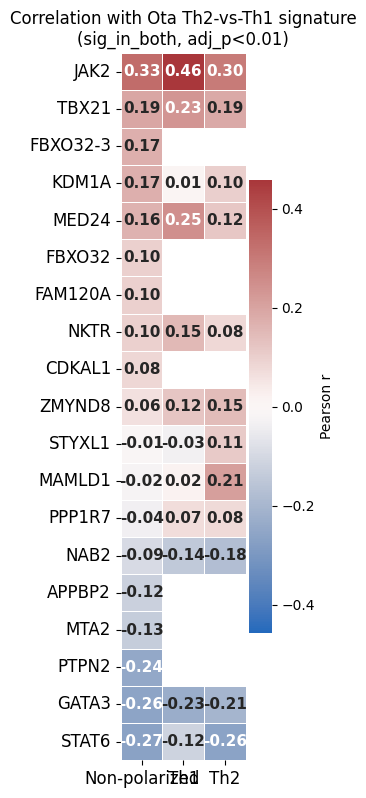

In [5]:
# Per-(perturbation, condition) Pearson correlation between the bulk DE z-score
# and the Ota Th2-vs-Th1 in-vivo signature z-score, evaluated on the
# sig_in_both gene set (Ota intersected with Hollbacker, adj_p<0.01) over
# every gene measured in both. Positive r = perturbation pushes cells toward
# the Th2 direction of the Ota signature; negative r = toward Th1.
sig_z = sig_in_both['zscore']

corr_rows = []
for (target, cond), grp in combined_de.groupby(['target_contrast_gene_name', 'condition']):
    sub = grp.dropna(subset=['zscore']).set_index('gene_name')
    sub = sub[~sub.index.duplicated(keep='first')]
    common = sub.index.intersection(sig_z.index)
    if len(common) < 5:
        continue
    r, p = stats.pearsonr(sig_z.loc[common].values,
                          sub.loc[common, 'zscore'].values)
    corr_rows.append({'perturbation': target, 'condition': cond,
                      'n_genes': len(common), 'pearson_r': r, 'p_value': p})

bulk_signature_corr = pd.DataFrame(corr_rows)
print(f'bulk_signature_corr: {bulk_signature_corr.shape}')
display(bulk_signature_corr.sort_values(['condition', 'pearson_r']).head(20))

# Heatmap: rows = perturbation (sorted by Th0 correlation), cols = condition.
piv = bulk_signature_corr.pivot(index='perturbation', columns='condition', values='pearson_r')
order_col = 'Th0' if 'Th0' in piv.columns else piv.columns[0]
piv = piv.loc[piv[order_col].sort_values(ascending=False).index,
              [c for c in ['Th0', 'Th1', 'Th2'] if c in piv.columns]]
absmax = float(np.nanmax(np.abs(piv.values)))

fig, ax = plt.subplots(figsize=(3.2, 0.32 * len(piv) + 2.0))
sns.heatmap(
    piv, cmap='vlag', center=0, vmin=-absmax, vmax=absmax,
    annot=True, fmt='.2f', annot_kws={'fontsize': 11, 'fontweight': 'bold'},
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Pearson r', 'shrink': 0.7, 'pad': 0.02},
    ax=ax,
)
ax.set_title('Correlation with Ota Th2-vs-Th1 signature\n(sig_in_both, adj_p<0.01)',
             fontsize=12)
ax.set_xticklabels([{'Th0': 'Non-polarized'}.get(t.get_text(), t.get_text())
                    for t in ax.get_xticklabels()])
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=12, rotation=0)
ax.tick_params(axis='y', labelsize=12, rotation=0)
plt.tight_layout()
plt.show()


In [6]:
display(bulk_summary[bulk_summary.perturbation == 'MED24'])

,perturbation,condition,measurement,n,mean_log2FC,mean_zscore,sem_zscore,p_value,adj_p_value
17,MED24,Th0,bulk_Th2,50,0.085814,0.293583,0.455219,0.521983,0.550982
18,MED24,Th1,bulk_Th2,50,0.198332,0.573787,0.261449,0.032959,0.087313
19,MED24,Th2,bulk_Th2,50,0.027967,0.502752,0.312232,0.113781,0.170671
60,MED24,Th0,bulk_Th1,48,-0.167528,-0.900017,0.532934,0.097883,0.169071
61,MED24,Th1,bulk_Th1,47,-0.255185,-0.669894,0.267452,0.015861,0.031721
62,MED24,Th2,bulk_Th1,48,-0.078568,-0.046172,0.250752,0.854699,0.854699


## 2. Flow cytometry quantifications

Two modular subsections, each producing a usable intermediate:

- **2.1** load all annotated CSVs into one long-format dataframe (`flow_long`)
- **2.2** compute per-donor log2FC vs NTCs (`flow_lfc`) and aggregate to `flow_summary`

### 2.0 (optional) Annotate a raw flow CSV with `Donor` / `perturbation`

Run this only on files that don't yet have Donor/perturbation columns.
Most CSVs in this folder are already annotated.

In [7]:
def annotate_flow_csv(csv_in, csv_out, col_to_gene,
                      sample_pattern=r'_Donor([A-Z])_[A-Z](\d+)\.fcs$'):
    """Add Donor + perturbation columns to a raw flow CSV by parsing the sample name.

    `col_to_gene` maps the integer well/column index (captured by the regex)
    to a perturbation label. Idempotent: if `Donor`/`perturbation` already
    exist they're dropped first so re-running is safe."""
    df = pd.read_csv(csv_in)
    df.columns = [c.strip() for c in df.columns]
    sample_col = df.columns[0]
    parsed = df[sample_col].str.extract(sample_pattern).rename(columns={0: 'Donor', 1: 'col'})
    parsed['col'] = parsed['col'].astype(int)
    parsed['perturbation'] = parsed['col'].map(col_to_gene)
    out = df.drop(columns=[c for c in ('Donor', 'perturbation') if c in df.columns]).copy()
    out.insert(1, 'Donor', parsed['Donor'].values)
    out.insert(2, 'perturbation', parsed['perturbation'].values)
    out.to_csv(csv_out, index=False)
    print(f'wrote {csv_out}  shape={out.shape}')
    return out


# Example (already run for TFRest_Th1):
# col_to_gene = {2:'NTC1', 3:'TBX21', 4:'GATA3', 5:'JAK2', 6:'STYXL1',
#                7:'MAMLD1', 8:'PPP1R7', 9:'NKTR', 10:'ZMYND8', 11:'NTC2'}
# annotate_flow_csv(
#     '/mnt/oak/users/emma/data/GWT/Th1Th2_validation_data/flow/Diff084Day22_TFRest_Th1_04172026.csv',
#     '/mnt/oak/users/emma/data/GWT/Th1Th2_validation_data/flow/Diff084Day22_TFRest_Th1_04172026.csv',
#     col_to_gene,

# )

In [8]:
col_to_gene = {2:'NTC1', 3:'TBX21', 4:'GATA3', 5:'JAK2', 6:'STYXL1',
               7:'MAMLD1', 8:'PPP1R7', 9:'NKTR', 10:'ZMYND8', 11:'NTC2'}
annotate_flow_csv(
    '/mnt/oak/users/emma/data/GWT/Th1Th2_validation_data/flow/Diff084Day22_TFRest_Th1_04172026.csv',
    '/mnt/oak/users/emma/data/GWT/Th1Th2_validation_data/flow/Diff084Day22_TFRest_Th1_04172026.csv',
    col_to_gene,
)

wrote /mnt/oak/users/emma/data/GWT/Th1Th2_validation_data/flow/Diff084Day22_TFRest_Th1_04172026.csv  shape=(29, 5)


,Sample:,Donor,perturbation,P1/P2/live | Median (VL1-A :: T-bet-Brilliant Violet 421-A),P1/P2/live | Median (YL1-A :: GATA-3-R-PE-A)
0,Diff084Day22_TF_Rest_Th1_04172026_Experiment_D...,A,NTC1,282,1119
1,Diff084Day22_TF_Rest_Th1_04172026_Experiment_D...,A,TBX21,231,1163
2,Diff084Day22_TF_Rest_Th1_04172026_Experiment_D...,A,GATA3,355,783
3,Diff084Day22_TF_Rest_Th1_04172026_Experiment_D...,A,JAK2,253,1119
4,Diff084Day22_TF_Rest_Th1_04172026_Experiment_D...,A,ZMYND8,311,1399
5,Diff084Day22_TF_Rest_Th1_04172026_Experiment_D...,B,NTC1,253,899
6,Diff084Day22_TF_Rest_Th1_04172026_Experiment_D...,B,TBX21,217,827
7,Diff084Day22_TF_Rest_Th1_04172026_Experiment_D...,B,MAMLD1,326,987
8,Diff084Day22_TF_Rest_Th1_04172026_Experiment_D...,B,PPP1R7,362,1046
9,Diff084Day22_TF_Rest_Th1_04172026_Experiment_D...,B,ZMYND8,326,1340


### 2.1 Load all flow CSVs into one long dataframe

Each row is one (sample, measurement) pair:
`[Sample, Donor, perturbation, condition, measurement, value]`.

In [9]:
def find_target_column(df, target):
    """Locate the column whose header contains `target` (case-insensitive,
    ignoring non-alphanumerics). 'IFNG' matches 'IFN-g'/'IFN gamma';
    use protein names like 'T-bet' for TF staining."""
    norm = lambda s: re.sub(r'[^0-9a-zA-Z]', '', s).lower()
    t = norm(target)
    return next((c for c in df.columns if t in norm(c)), None)


def load_flow_csv(csv_path, condition, targets):
    """Read one annotated CSV and melt the listed `targets` into long format."""
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    sample_col = df.columns[0]
    pieces = []
    for t in targets:
        col = find_target_column(df, t)
        if col is None:
            data_cols = [c for c in df.columns if c not in (sample_col, 'Donor', 'perturbation')]
            raise ValueError(f"target '{t}' not found in {csv_path}. Columns: {data_cols}")
        piece = pd.DataFrame({
            'Sample': df[sample_col].values,
            'Donor': df['Donor'].values,
            'perturbation': df['perturbation'].values,
            'condition': condition,
            'measurement': t,
            'value': df[col].values,
        })
        pieces.append(piece)
    return pd.concat(pieces, ignore_index=True)


def load_all_flow(file_specs, base_dir=''):
    """`file_specs` is a list of (csv_path, condition_label, [targets])."""
    dfs = []
    for path, cond, targets in file_specs:
        full = f'{base_dir}/{path}' if base_dir else path
        dfs.append(load_flow_csv(full, cond, targets))
    return pd.concat(dfs, ignore_index=True)


def load_diff081_flow(xls_path,
                      gate_cols=('IFNg+', 'IL5+'),
                      condition='IGG_nonpolarized',
                      guide_to_target=None,
                      measurement_rename=None):
    """Load the Diff081 arrayed-screen FACS Excel and convert to the long
    `flow_long` schema as `load_flow_csv`.

    `gate_cols` lists the cytokine-gate frequency columns to include (values
    are 'XX.X %' strings). `guide_to_target` maps guide labels (e.g.
    'F-32-2', 'F120A-1') to gene-level perturbation names so FACS rows align
    with bulk DE rows on `target_contrast_gene_name`. `measurement_rename`
    is an optional dict mapping source gate names to canonical measurement
    names (e.g. {'IFNg+': 'IFNG', 'IL5+': 'IL5'}) so Diff081 rows pivot into
    the same heatmap columns as the matching Diff084 IGG measurements."""
    df = pd.read_excel(xls_path)
    df = df[~df['Unnamed: 0'].astype(str).isin(['Mean', 'SD'])].copy()
    df['Donor'] = df['Donor'].astype(str).str.strip()
    for col in gate_cols:
        if df[col].dtype == object:
            df[col] = df[col].astype(str).str.replace('%', '').str.strip().astype(float)
    if guide_to_target:
        df['perturbation'] = df['Guide'].replace(guide_to_target)
    else:
        df['perturbation'] = df['Guide']
    sample_col = 'Unnamed: 0' if 'Unnamed: 0' in df.columns else df.columns[0]
    rename = measurement_rename or {}
    pieces = []
    for col in gate_cols:
        pieces.append(pd.DataFrame({
            'Sample': df[sample_col].astype(str).values,
            'Donor': df['Donor'].values,
            'perturbation': df['perturbation'].values,
            'condition': condition,
            'measurement': rename.get(col, col),
            'value': df[col].values,
        }))
    return pd.concat(pieces, ignore_index=True)


In [10]:
ls ../../../../3_expts/Cell_culture_experiments/Th1Th2_validation_all/flow/summary

ls: cannot access '../../../../3_expts/Cell_culture_experiments/Th1Th2_validation_all/flow/summary': No such file or directory


In [11]:
# # Flow data: Diff084 (full panel), Diff088 (nonpolarized only), Diff089 (IGG only).
# # Diff081 flow analysis (Diff081_Analysis.xls) used an older staining/gating
# # protocol and is excluded from the validation comparison.
# FLOW_DIR = '/mnt/oak/users/emma/data/GWT/Th1Th2_validation_data/flow'

# FLOW_FILES = [
#     ('Diff084', 'Diff084Day22_IGG_nonpolarized_04172026.csv', 'IGG_nonpolarized', ['IFNG', 'IL5']),
#     ('Diff084', 'Diff084Day22_IGG_Th1_04172026.csv', 'IGG_Th1', ['IFNG', 'IL5']),
#     ('Diff084', 'Diff084Day22_IGG_Th2_04172026.csv', 'IGG_Th2', ['IFNG', 'IL5']),
#     ('Diff084', 'Diff084Day22_TFRest_nonpolarized_04172026.csv', 'TFRest_nonpolarized', ['T-bet', 'GATA-3']),
#     ('Diff084', 'Diff084Day22_TFRest_Th1_04172026.csv', 'TFRest_Th1', ['T-bet', 'GATA-3']),
#     ('Diff084', 'Diff084Day22_TFRest_Th2_04172026.csv', 'TFRest_Th2', ['T-bet', 'GATA-3']),
#     ('Diff088', 'Diff088Day22_IGG_nonpolarized_05032026.csv', 'IGG_nonpolarized', ['IFNG', 'IL5']),
#     ('Diff088', 'Diff088Day22_TFRest_nonpolarized_05032026.csv', 'TFRest_nonpolarized', ['T-bet', 'GATA-3']),
#     ('Diff089', 'Diff089Day23_IGG_nonpolarized_05072026.csv', 'IGG_nonpolarized', ['IFNG', 'IL5']),
#     ('Diff089', 'Diff089Day23_IGG_Th1_05072026.csv', 'IGG_Th1', ['IFNG', 'IL5']),
#     ('Diff089', 'Diff089Day23_IGG_Th2_05072026.csv', 'IGG_Th2', ['IFNG', 'IL5']),
# ]

# pieces = []
# for batch, fname, cond, targets in FLOW_FILES:
#     df_b = load_all_flow([(fname, cond, targets)], base_dir=FLOW_DIR)
#     df_b['batch'] = batch
#     pieces.append(df_b)
# flow_long = pd.concat(pieces, ignore_index=True)

# print(f'flow_long: {flow_long.shape}')
# print(flow_long.groupby(['batch', 'condition']).size().rename('n_rows'))
# display(flow_long.head())

# flow_save_path = '../../metadata/Th1Th2_validation_flow.csv'
# flow_long.to_csv(flow_save_path, index=False)

In [12]:
flow_save_path = '../../metadata/Th1Th2_validation_flow.csv'
flow_long = pd.read_csv(flow_save_path)

### 2.2 Per-batch / per-donor log2FC, then aggregate across donors

- `compute_log2fc_per_donor` returns a per-sample long dataframe with `log2FC`
  filled in (and the per-batch NTC reference for inspection). The NTC mean is
  computed **within each (batch, donor, condition, measurement)** group, so
  Diff081 and Diff084 NTCs are never mixed even when they share a
  `(condition, measurement)` column. NTC samples themselves get a `log2FC`
  computed against their batch's NTC mean — used as the comparison group below.
- `summarize_log2fc` aggregates across donors per (perturbation, condition,
  measurement) and runs a Welch two-sample t-test of the perturbation's
  log2FCs vs the NTC log2FCs from the same batch(es).

In [13]:
def compute_log2fc_per_donor(long_df, ntc_names=('NTC1', 'NTC2', 'NTC')):
    """For each (batch, Donor, condition, measurement) compute mean(NTC value)
    and return long_df with `ntc_mean` and `log2FC = log2(value / ntc_mean)`.
    Batch is part of the grouping so Diff081 NTCs (single 'NTC' guide) are
    never mixed with Diff084 NTCs (NTC1/NTC2). NTC samples themselves get a
    log2FC computed against their batch's NTC mean and are used downstream as
    the comparison group in summarize_log2fc."""
    ntc_mean = (long_df[long_df['perturbation'].isin(ntc_names)]
                .groupby(['batch', 'Donor', 'condition', 'measurement'])['value']
                .mean()
                .rename('ntc_mean')
                .reset_index())
    out = long_df.merge(ntc_mean,
                        on=['batch', 'Donor', 'condition', 'measurement'],
                        how='left')
    out['log2FC'] = np.log2(out['value'] / out['ntc_mean'])
    return out


def summarize_log2fc(lfc_df, ntc_names=('NTC1', 'NTC2', 'NTC'),
                     correction_group=('condition', 'measurement')):
    """Aggregate across donors per (perturbation, condition, measurement) and
    run a Welch two-sample t-test of the perturbation's log2FCs vs the NTC
    log2FCs from the same batch(es). NTC log2FCs are non-zero (each NTC
    sample is divided by its donor's NTC mean within its batch), so they
    form a real null distribution rather than a degenerate point at zero.

    Returns one row per group with `n` (perturbation samples), `mean_log2FC`,
    `n_ntc` (NTC samples used as comparison), `p_value`, and BH-adjusted
    `adj_p_value` computed within each `correction_group`."""
    rows = []
    is_ntc = lfc_df['perturbation'].isin(ntc_names)
    non_ntc = lfc_df[~is_ntc]
    for (perturb, cond, meas), sub in non_ntc.groupby(['perturbation', 'condition', 'measurement']):
        batches = sub['batch'].unique().tolist()
        pert_vals = sub['log2FC'].dropna().values
        ntc_sub = lfc_df[is_ntc &
                         (lfc_df['condition'] == cond) &
                         (lfc_df['measurement'] == meas) &
                         (lfc_df['batch'].isin(batches))]
        ntc_vals = ntc_sub['log2FC'].dropna().values
        n = len(pert_vals)
        n_ntc = len(ntc_vals)
        m = pert_vals.mean() if n else np.nan
        if n >= 2 and n_ntc >= 2:
            _, p = stats.ttest_ind(pert_vals, ntc_vals, equal_var=False)
        else:
            p = np.nan
        rows.append({'perturbation': perturb, 'condition': cond, 'measurement': meas,
                     'n': n, 'n_ntc': n_ntc, 'mean_log2FC': m, 'p_value': p})
    summary = pd.DataFrame(rows)
    if correction_group is not None and len(summary):
        summary = bh_adjust_within(summary, group_cols=correction_group)
    return summary


In [14]:
flow_lfc = compute_log2fc_per_donor(flow_long, ntc_names=('NTC1', 'NTC2', 'NTC'))
flow_summary = summarize_log2fc(flow_lfc, ntc_names=('NTC1', 'NTC2', 'NTC'))

print(f'flow_lfc: {flow_lfc.shape}   flow_summary: {flow_summary.shape}')
display(flow_summary)


flow_lfc: (816, 9)   flow_summary: (132, 8)


,perturbation,condition,measurement,n,n_ntc,mean_log2FC,p_value,adj_p_value
0,GATA3,IGG_Th1,IFNG,5,11,0.404282,0.093082,0.242837
1,GATA3,IGG_Th1,IL5,5,11,-1.290064,0.000452,0.002712
2,GATA3,IGG_Th2,IFNG,5,12,0.940463,0.075674,0.181618
3,GATA3,IGG_Th2,IL5,5,12,-0.091589,0.955794,0.955794
4,GATA3,IGG_nonpolarized,IFNG,5,12,0.491675,0.158315,0.294013
...,...,...,...,...,...,...,...,...
127,ZMYND8,TFRest_Th1,T-bet,3,7,0.134329,0.080478,0.202925
128,ZMYND8,TFRest_Th2,GATA-3,6,12,0.081586,0.391034,0.391034
129,ZMYND8,TFRest_Th2,T-bet,6,12,0.004621,0.891506,0.891506
130,ZMYND8,TFRest_nonpolarized,GATA-3,5,11,0.230952,0.004253,0.055293


In [15]:
flow_lfc[flow_lfc.perturbation == 'GATA3']

,Sample,Donor,perturbation,condition,measurement,value,batch,ntc_mean,log2FC
2,Diff084Day22_IGG_nonpolarized_04172026_Experim...,A,GATA3,IGG_nonpolarized,IFNG,20.300,Diff084,11.100,0.870920
18,Diff084Day22_IGG_nonpolarized_04172026_Experim...,C,GATA3,IGG_nonpolarized,IFNG,12.400,Diff084,4.840,1.357261
28,Diff084Day22_IGG_nonpolarized_04172026_Experim...,E,GATA3,IGG_nonpolarized,IFNG,43.700,Diff084,32.250,0.438334
36,Diff084Day22_IGG_nonpolarized_04172026_Experim...,F,GATA3,IGG_nonpolarized,IFNG,26.700,Diff084,26.250,0.024522
46,Diff084Day22_IGG_nonpolarized_04172026_Experim...,G,GATA3,IGG_nonpolarized,IFNG,20.000,Diff084,23.500,-0.232661
56,Diff084Day22_IGG_nonpolarized_04172026_Experim...,A,GATA3,IGG_nonpolarized,IL5,4.770,Diff084,5.550,-0.218499
72,Diff084Day22_IGG_nonpolarized_04172026_Experim...,C,GATA3,IGG_nonpolarized,IL5,2.830,Diff084,4.350,-0.620213
82,Diff084Day22_IGG_nonpolarized_04172026_Experim...,E,GATA3,IGG_nonpolarized,IL5,0.620,Diff084,2.280,-1.878694
90,Diff084Day22_IGG_nonpolarized_04172026_Experim...,F,GATA3,IGG_nonpolarized,IL5,0.490,Diff084,0.570,-0.218180
100,Diff084Day22_IGG_nonpolarized_04172026_Experim...,G,GATA3,IGG_nonpolarized,IL5,0.640,Diff084,1.515,-1.243174


In [16]:
flow_lfc

,Sample,Donor,perturbation,condition,measurement,value,batch,ntc_mean,log2FC
0,Diff084Day22_IGG_nonpolarized_04172026_Experim...,A,NTC1,IGG_nonpolarized,IFNG,10.00,Diff084,11.10,-0.150560
1,Diff084Day22_IGG_nonpolarized_04172026_Experim...,A,TBX21,IGG_nonpolarized,IFNG,5.92,Diff084,11.10,-0.906891
2,Diff084Day22_IGG_nonpolarized_04172026_Experim...,A,GATA3,IGG_nonpolarized,IFNG,20.30,Diff084,11.10,0.870920
3,Diff084Day22_IGG_nonpolarized_04172026_Experim...,A,JAK2,IGG_nonpolarized,IFNG,7.75,Diff084,11.10,-0.518291
4,Diff084Day22_IGG_nonpolarized_04172026_Experim...,A,STYXL1,IGG_nonpolarized,IFNG,11.60,Diff084,11.10,0.063565
...,...,...,...,...,...,...,...,...,...
811,Diff089Day23_IGG_Th2_05072026_Experiment_Donor...,F,MED24,IGG_Th2,IL5,3.45,Diff089,2.57,0.424828
812,Diff089Day23_IGG_Th2_05072026_Experiment_Donor...,F,KDM1A,IGG_Th2,IL5,0.71,Diff089,2.57,-1.855877
813,Diff089Day23_IGG_Th2_05072026_Experiment_Donor...,F,STAT6,IGG_Th2,IL5,0.12,Diff089,2.57,-4.420662
814,Diff089Day23_IGG_Th2_05072026_Experiment_Donor...,F,NAB2,IGG_Th2,IL5,1.97,Diff089,2.57,-0.383573


In [17]:
# Heatmap row order:
# - TBX21 pinned to top (Th1 positive control)
# - GATA3 pinned to bottom (Th2 positive control)
# - all other perturbations present in either summary, sorted descending by
#   predicted effect on the Ota Th2-vs-Th1 polarization signature
#   (positive = pushes Th2, negative = pushes Th1; missing pred -> end of middle).
# - FBXO32-3 (alt guide for FBXO32) is excluded from all heatmaps.
_pred = pd.read_csv('results/polarization_prediction_condition_comparison.regulator_coefficients.csv',
                    index_col=0)
_pred = _pred[(_pred['signature'] == 'ota') & (_pred['celltype'] == 'Stim8hr')]
pred_effect = _pred.set_index('regulator')['coef_mean']

PINNED_TOP = ['TBX21']
PINNED_BOT = ['GATA3']
EXCLUDE = {'FBXO32-3'}
all_targets = (set(bulk_summary['perturbation']) | set(flow_summary['perturbation'])) - EXCLUDE
middle = [t for t in all_targets if t not in set(PINNED_TOP) | set(PINNED_BOT)]
present = [t for t in middle if t in pred_effect.index]
missing_in_pred = [t for t in middle if t not in pred_effect.index]
middle_sorted = sorted(present, key=pred_effect.get, reverse=True) + missing_in_pred
perturbation_order = PINNED_TOP + middle_sorted + PINNED_BOT
print('row order:', perturbation_order)
print('pred_effect:',
      {t: (round(float(pred_effect.get(t, float('nan'))), 3) if t in pred_effect.index else None)
       for t in middle_sorted})


row order: ['TBX21', 'JAK2', 'KDM1A', 'MED24', 'NKTR', 'ZMYND8', 'MTA2', 'MAMLD1', 'STYXL1', 'PPP1R7', 'PTPN2', 'FAM120A', 'STAT6', 'NAB2', 'APPBP2', 'FBXO32', 'CDKAL1', 'GATA3']
pred_effect: {'JAK2': 0.039, 'KDM1A': 0.03, 'MED24': 0.029, 'NKTR': 0.02, 'ZMYND8': 0.019, 'MTA2': -0.021, 'MAMLD1': -0.025, 'STYXL1': -0.027, 'PPP1R7': -0.028, 'PTPN2': -0.028, 'FAM120A': -0.032, 'STAT6': -0.032, 'NAB2': -0.035, 'APPBP2': -0.036, 'FBXO32': -0.041, 'CDKAL1': -0.043}


## 3. Main figure heatmap

In [18]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


def plot_heatmap(summary_df, perturbations=None, measurements=None,
                 value_col='mean_log2FC', p_col='adj_p_value',
                 star_threshold=0.05,
                 cmap='RdBu_r', vmin=None, vmax=None,
                 cbar=True, cbar_label=None, cbar_loc='top',
                 yticklabels=True, xlabel=None,
                 tick_fontsize=14, title_fontsize=16,
                 cbar_fontsize=12, annot_fontsize=16, xlabel_fontsize=13,
                 xtick_rotation=45,
                 figsize=None, column_label_format=None, title=None, ax=None):
    """Heatmap of perturbations (rows) x (condition, measurement) (cols).

    Cells annotated with `*` where `p_col` < star_threshold. Colorbar can be
    placed `cbar_loc='top'` (horizontal, above the panel) or `'right'`
    (default seaborn vertical bar). All visible text sizes are exposed as
    arguments so panels can scale fontsize independently of figure size.
    """
    if column_label_format is None:
        column_label_format = lambda cond, meas: f'{cond}\n{meas}'
    if cbar_label is None:
        cbar_label = value_col

    df = summary_df.copy()
    df['col_key'] = list(zip(df['condition'], df['measurement']))

    if measurements is None:
        measurements = sorted(df['col_key'].unique())
    if perturbations is None:
        perturbations = sorted(df['perturbation'].unique())

    val_mat = (df.pivot(index='perturbation', columns='col_key', values=value_col)
                 .reindex(index=perturbations, columns=measurements))
    p_mat = (df.pivot(index='perturbation', columns='col_key', values=p_col)
               .reindex(index=perturbations, columns=measurements))

    if vmax is None:
        absmax = np.nanmax(np.abs(val_mat.values)) if val_mat.size else 1.0
        if not np.isfinite(absmax) or absmax == 0:
            absmax = 1.0
        vmax = float(absmax)
    if vmin is None:
        vmin = -vmax

    annot = np.where(
        (~p_mat.isna()) & (p_mat < star_threshold),
        '*', '',
    )

    n_rows, n_cols = val_mat.shape
    if ax is None:
        if figsize is None:
            figsize = (max(3, 0.45 * n_cols + 1.2),
                       max(2.5, 0.32 * n_rows + 1.5))
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    yticks_arg = perturbations if yticklabels is True else yticklabels

    if cbar and cbar_loc == 'top':
        divider = make_axes_locatable(ax)
        cax = divider.append_axes('top', size='4%', pad=0.45)
        cbar_kws = {'orientation': 'horizontal', 'label': cbar_label}
        cbar_ax = cax
        draw_cbar = True
    elif cbar:
        cax = None
        cbar_kws = {'label': cbar_label, 'shrink': 0.7, 'pad': 0.02}
        cbar_ax = None
        draw_cbar = True
    else:
        cax = None
        cbar_kws = None
        cbar_ax = None
        draw_cbar = False

    sns.heatmap(
        val_mat.values,
        annot=annot, fmt='',
        cmap=cmap, center=0, vmin=vmin, vmax=vmax,
        cbar=draw_cbar, cbar_ax=cbar_ax, cbar_kws=cbar_kws,
        linewidths=0.5, linecolor='white',
        xticklabels=[column_label_format(*k) for k in measurements],
        yticklabels=yticks_arg,
        annot_kws={'fontsize': annot_fontsize, 'fontweight': 'bold'},
        ax=ax,
    )

    if draw_cbar and cax is not None:
        cax.xaxis.set_label_position('top')
        cax.xaxis.set_ticks_position('top')
        cax.tick_params(labelsize=cbar_fontsize - 1)
        cax.xaxis.label.set_size(cbar_fontsize)

    ax.tick_params(axis='x', labelsize=tick_fontsize, rotation=xtick_rotation)
    if xtick_rotation != 0:
        for label in ax.get_xticklabels():
            label.set_ha('right')
    else:
        for label in ax.get_xticklabels():
            label.set_ha('center')
    ax.tick_params(axis='y', labelsize=tick_fontsize, rotation=0)
    ax.set_ylabel('')

    if xlabel:
        ax.set_xlabel(xlabel, fontsize=xlabel_fontsize)
    if title:
        # When the cbar lives on top of the panel, the title would collide
        # with it -- promote the title onto the cbar axis instead.
        if cbar and cbar_loc == 'top' and cax is not None:
            cax.set_title(title, fontsize=title_fontsize, pad=10)
        else:
            ax.set_title(title, fontsize=title_fontsize)
    return fig, ax, val_mat, p_mat


def plot_heatmap_blocks(summary_df, blocks, perturbations=None,
                        p_col='p_value', star_threshold=0.05,
                        figsize=None, suptitle=None,
                        column_label_format=None,
                        cbar_loc='top',
                        group_gap=0.6,
                        tick_fontsize=14, title_fontsize=16,
                        cbar_fontsize=12, annot_fontsize=16,
                        xlabel_fontsize=13, xtick_rotation=45):
    """Multi-panel heatmap. Each block is a column-group with its own
    `value_col`, colormap and colorbar; rows (perturbations) are shared
    across panels. Per-block `xlabel` and `column_label_format` are
    supported via the block dict (block-level overrides win).

    Optional grouping: blocks that set the same `'group'` value share a
    single colorbar (and a common vmin/vmax computed from their pooled
    data), sit flush against each other (no horizontal padding), and are
    separated from other groups by a `group_gap`-inch spacer column.
    Blocks without `'group'` keep the original per-block-cbar behaviour.
    """
    from collections import OrderedDict
    from matplotlib.gridspec import GridSpec
    from matplotlib.colors import Normalize
    from matplotlib.cm import ScalarMappable

    if perturbations is None:
        perturbations = sorted(summary_df['perturbation'].unique())
    n_rows = len(perturbations)

    # Per-block width: explicit `width` in the block dict wins; otherwise
    # auto-size from the number of columns. Used both for gridspec
    # `width_ratios` and (when figsize is None) for total figure width.
    widths = [b.get('width', max(1.6, 0.5 * len(b['measurements']) + 1.5))
              for b in blocks]

    has_groups = any('group' in b for b in blocks)

    # ---------------------------------------------------------------
    # Path 1: original (per-block colorbars, no grouping). Untouched
    # behaviour for every existing call site.
    # ---------------------------------------------------------------
    if not has_groups:
        if figsize is None:
            figsize = (sum(widths), max(2.5, 0.32 * n_rows + 2.0))

        fig, axes = plt.subplots(
            1, len(blocks), figsize=figsize,
            gridspec_kw={'width_ratios': widths},
        )
        if len(blocks) == 1:
            axes = [axes]

        for i, (ax, block) in enumerate(zip(axes, blocks)):
            plot_heatmap(
                summary_df,
                perturbations=perturbations,
                measurements=block['measurements'],
                value_col=block.get('value_col', 'mean_log2FC'),
                p_col=p_col,
                star_threshold=star_threshold,
                cmap=block.get('cmap', 'RdBu_r'),
                vmin=block.get('vmin'),
                vmax=block.get('vmax'),
                cbar=True,
                cbar_loc=cbar_loc,
                cbar_label=block.get('cbar_label', block.get('value_col', 'mean_log2FC')),
                yticklabels=(i == 0),
                xlabel=block.get('xlabel'),
                column_label_format=block.get('column_label_format', column_label_format),
                title=block.get('title'),
                tick_fontsize=tick_fontsize,
                title_fontsize=title_fontsize,
                cbar_fontsize=cbar_fontsize,
                annot_fontsize=annot_fontsize,
                xlabel_fontsize=xlabel_fontsize,
                xtick_rotation=xtick_rotation,
                ax=ax,
            )

        if suptitle:
            fig.suptitle(suptitle, y=1.0, fontsize=title_fontsize + 6, fontweight='bold')
        plt.tight_layout()
        return fig, axes

    # ---------------------------------------------------------------
    # Path 2: grouped layout. Blocks sharing a `group` key share a
    # colorbar / vmin / vmax and sit flush; groups are separated by
    # `group_gap`-inch spacer columns.
    # ---------------------------------------------------------------
    group_keys = [b.get('group', f'__solo_{i}') for i, b in enumerate(blocks)]
    grouped = OrderedDict()
    for i, gid in enumerate(group_keys):
        grouped.setdefault(gid, []).append(i)
    group_to_indices = list(grouped.items())

    df = summary_df.copy()
    df['col_key'] = list(zip(df['condition'], df['measurement']))

    # Per-group: pool all (cond, meas) tuples in the group and compute a
    # symmetric vmin/vmax from the pooled values (unless any block in the
    # group sets vmin/vmax explicitly -- first non-None wins).
    group_meta = {}
    for gid, idxs in group_to_indices:
        ref = blocks[idxs[0]]
        value_col = ref.get('value_col', 'mean_log2FC')
        cmap = ref.get('cmap', 'RdBu_r')
        cbar_label = ref.get('cbar_label', value_col)
        for j in idxs:
            b = blocks[j]
            assert b.get('value_col', 'mean_log2FC') == value_col, (
                f"group {gid!r}: block {j} uses value_col="
                f"{b.get('value_col')}, but the group leader uses "
                f"{value_col}. Blocks sharing a colorbar must use the "
                f"same value_col and cmap."
            )
            assert b.get('cmap', 'RdBu_r') == cmap, (
                f"group {gid!r}: block {j} uses cmap={b.get('cmap')}, "
                f"but the group leader uses {cmap}."
            )
        keys = []
        for j in idxs:
            keys.extend(blocks[j]['measurements'])
        sub = df[df['col_key'].isin(keys)]
        explicit_vmax = next((blocks[j].get('vmax') for j in idxs
                              if blocks[j].get('vmax') is not None), None)
        explicit_vmin = next((blocks[j].get('vmin') for j in idxs
                              if blocks[j].get('vmin') is not None), None)
        if explicit_vmax is None:
            vals = sub[value_col].values
            absmax = np.nanmax(np.abs(vals)) if len(vals) else 1.0
            if not np.isfinite(absmax) or absmax == 0:
                absmax = 1.0
            vmax = float(absmax)
        else:
            vmax = float(explicit_vmax)
        vmin = float(explicit_vmin) if explicit_vmin is not None else -vmax
        group_meta[gid] = dict(value_col=value_col, cmap=cmap,
                               vmin=vmin, vmax=vmax, cbar_label=cbar_label)

    # Build column layout: alternating block columns and (between groups
    # only) spacer columns of width `group_gap`. wspace=0 across the
    # whole row so within-group blocks touch.
    cols = []
    for gi, (gid, idxs) in enumerate(group_to_indices):
        if gi > 0:
            cols.append(('gap', None))
        for j in idxs:
            cols.append(('block', j))
    col_widths = [widths[c[1]] if c[0] == 'block' else group_gap for c in cols]

    if figsize is None:
        figsize = (sum(col_widths), max(2.5, 0.32 * n_rows + 2.4))

    fig = plt.figure(figsize=figsize)
    gs = GridSpec(1, len(cols), figure=fig,
                  width_ratios=col_widths, wspace=0.0)

    axes_by_block = [None] * len(blocks)
    for ci, c in enumerate(cols):
        if c[0] == 'block':
            axes_by_block[c[1]] = fig.add_subplot(gs[0, ci])

    first_overall = group_to_indices[0][1][0]
    for gid, idxs in group_to_indices:
        meta = group_meta[gid]
        for bi in idxs:
            block = blocks[bi]
            ax = axes_by_block[bi]
            plot_heatmap(
                summary_df,
                perturbations=perturbations,
                measurements=block['measurements'],
                value_col=meta['value_col'],
                p_col=p_col,
                star_threshold=star_threshold,
                cmap=meta['cmap'],
                vmin=meta['vmin'],
                vmax=meta['vmax'],
                cbar=False,                       # shared cbar drawn below
                cbar_loc=cbar_loc,
                cbar_label=meta['cbar_label'],
                yticklabels=(bi == first_overall),
                xlabel=block.get('xlabel'),
                column_label_format=block.get('column_label_format', column_label_format),
                title=block.get('title'),
                tick_fontsize=tick_fontsize,
                title_fontsize=title_fontsize,
                cbar_fontsize=cbar_fontsize,
                annot_fontsize=annot_fontsize,
                xlabel_fontsize=xlabel_fontsize,
                xtick_rotation=xtick_rotation,
                ax=ax,
            )
            # Hide y-axis tick marks for any non-first-overall block (the
            # rows are shared, so the marks would just clutter the merged
            # heatmap). Hide internal vertical spines so blocks within a
            # group read as one continuous heatmap.
            if bi != first_overall:
                ax.tick_params(axis='y', left=False, labelleft=False)
            if bi != idxs[0]:
                ax.spines['left'].set_visible(False)
            if bi != idxs[-1]:
                ax.spines['right'].set_visible(False)

    if suptitle:
        fig.suptitle(suptitle, y=1.0, fontsize=title_fontsize + 6, fontweight='bold')
    plt.tight_layout()
    fig.canvas.draw()  # ensure subplot positions are settled before
                       # placing the manual cbars below

    # One shared horizontal colorbar above each group, spanning the
    # group's axes.
    for gid, idxs in group_to_indices:
        meta = group_meta[gid]
        boxes = [axes_by_block[bi].get_position() for bi in idxs]
        x0 = min(b.x0 for b in boxes)
        x1 = max(b.x1 for b in boxes)
        y_top = max(b.y1 for b in boxes)
        cbar_h = 0.018
        cbar_pad = 0.075  # tune if cbar overlaps per-block titles
        cax = fig.add_axes([x0, y_top + cbar_pad, x1 - x0, cbar_h])
        sm = ScalarMappable(norm=Normalize(vmin=meta['vmin'], vmax=meta['vmax']),
                            cmap=meta['cmap'])
        sm.set_array([])
        cb = fig.colorbar(sm, cax=cax, orientation='horizontal')
        cb.set_label(meta['cbar_label'], fontsize=cbar_fontsize)
        cax.tick_params(labelsize=cbar_fontsize - 1)
        cax.xaxis.set_label_position('top')
        cax.xaxis.set_ticks_position('top')

    return fig, axes_by_block

row order: ['JAK2', 'TBX21', 'MED24', 'ZMYND8', 'NKTR', 'KDM1A', 'STYXL1', 'NAB2', 'PPP1R7', 'MTA2', 'STAT6', 'GATA3']


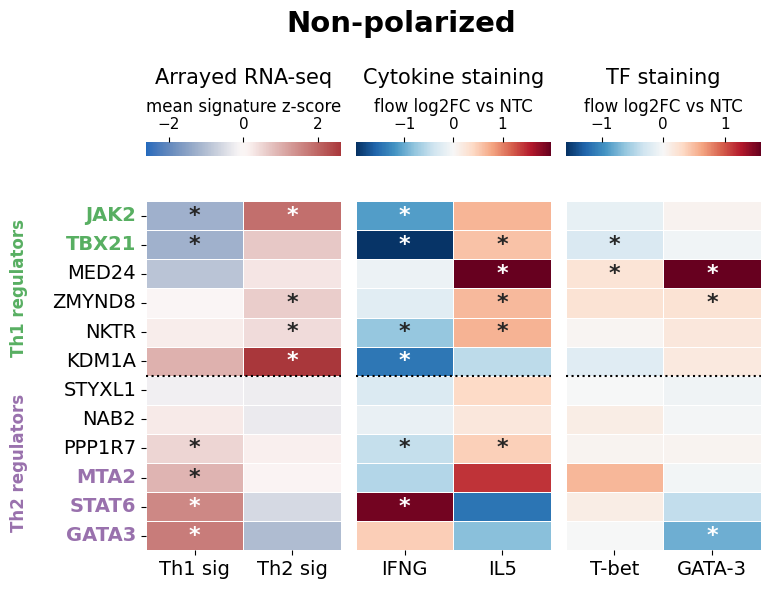

In [19]:
import yaml

# Novel targets surfaced by the perturb-seq screen and validated here.
# Kept in plain black on the y-axis so the known regulators stand out.
NOVEL_TARGETS = ['MED24', 'NKTR', 'ZMYND8', 'MAMLD1', 'STYXL1', "KDM1A",
                 'PPP1R7', 'NAB2']

# Targets that failed perturbation quality control or with missing data
exclude_lowQ = ['FBXO32', 'CDKAL1', 'FAM120A', 'PTPN2', 'APPBP2', 'MAMLD1']

# Tick label colors: only the *known* regulators (everything not in
# NOVEL_TARGETS) are coloured + bolded by predicted Th1/Th2 class. Novel
# targets stay plain black so the prior-known panel reads at a glance.
# TBX21 and GATA3 are pinned controls; assign by biology. FBXO32-3 inherits
# from FBXO32 (same gene, alt guide). Targets absent from pred_effect fall
# back to the neutral "control" colour.
with open('../../metadata/figure_palettes.yaml') as f:
    _palette = yaml.safe_load(f)
TH1_COLOR = _palette['regulator_predictions']['negative']
TH2_COLOR = _palette['regulator_predictions']['positive']
CONTROL_COLOR = _palette['regulator_predictions']['control']

def predicted_class(target):
    """'Th1' / 'Th2' / None based on pinned biology + pred_effect sign."""
    if target == 'TBX21':
        return 'Th1'
    if target == 'GATA3':
        return 'Th2'
    lookup = 'FBXO32' if target == 'FBXO32-3' else target
    if lookup in pred_effect.index:
        return 'Th2' if pred_effect[lookup] < 0 else 'Th1'
    return None

def regulator_label_color(target):
    if target in NOVEL_TARGETS:
        return 'black'
    cls = predicted_class(target)
    if cls == 'Th1':
        return TH1_COLOR
    if cls == 'Th2':
        return TH2_COLOR
    return CONTROL_COLOR

def regulator_label_weight(target):
    return 'normal' if target in NOVEL_TARGETS else 'bold'

def th1_th2_boundary(perturbations):
    """Row index of the first Th2 regulator in `perturbations`. Used to draw
    a dotted separator and place the Th1/Th2 group labels."""
    for i, t in enumerate(perturbations):
        if predicted_class(t) == 'Th2':
            return i
    return len(perturbations)

def style_regulator_axis(axes, perturbations, label_x=-0.65, left_margin=0.16,
                         boundary_offset=0.0, fontsize=12):
    """Colour known regulators by class, bold them, dotted line at the
    Th1/Th2 boundary across *all* heatmap panels, and 'Th1 regulators' /
    'Th2 regulators' side labels on the leftmost panel.

    `axes` may be a single Axes or a list of heatmap Axes (one per block);
    the dotted separator is drawn on each. `label_x` is the x position
    (axes coords) for the group labels; push it more negative to clear
    longer tick labels. `left_margin` widens the figure's left padding so
    the group labels don't get clipped (overrides the prior tight_layout
    left value)."""
    if hasattr(axes, 'get_yticklabels'):
        axes = [axes]
    ax0 = axes[0]
    for lbl in ax0.get_yticklabels():
        t = lbl.get_text()
        lbl.set_color(regulator_label_color(t))
        lbl.set_fontweight(regulator_label_weight(t))
    boundary = th1_th2_boundary(perturbations)
    n = len(perturbations)
    for ax in axes:
        ax.axhline(boundary + boundary_offset, color='black', linestyle=':', linewidth=1.5)
    trans = ax0.get_yaxis_transform()  # x in axes coords, y in data coords
    ax0.text(label_x, boundary / 2 + boundary_offset, 'Th1 regulators', transform=trans,
             rotation=90, va='center', ha='center',
             fontsize=fontsize, color=TH1_COLOR, fontweight='bold')
    ax0.text(label_x, (boundary + n) / 2 + boundary_offset, 'Th2 regulators', transform=trans,
             rotation=90, va='center', ha='center',
             fontsize=fontsize, color=TH2_COLOR, fontweight='bold')
    ax0.figure.subplots_adjust(left=left_margin)

def bulk_columns(condition):
    """Two-column bulk panel: Th1 signature on the left, Th2 on the right."""
    return [(condition, 'bulk_Th1'), (condition, 'bulk_Th2')]

def bulk_label(_cond, meas):
    """'bulk_Th1' -> 'Th1 sig' for the column tick label."""
    return meas.replace('bulk_', '') + ' sig'

combined_summary = pd.concat([bulk_summary, flow_summary], ignore_index=True)
combined_summary = combined_summary[~combined_summary.perturbation.isin(exclude_lowQ)].copy()
plot_perturbations = [t for t in perturbation_order if t not in exclude_lowQ]

# Re-sort within each Th1/Th2 group by mean effect on the bulk_Th1 signature
# (Th0 condition -- the first column of every heatmap panel below). TBX21
# stays pinned at the top and GATA3 at the bottom; targets with no Th0
# bulk value fall to the end of their group.
_th1_sort_key = (bulk_summary[(bulk_summary['condition'] == 'Th0')
                              & (bulk_summary['measurement'] == 'bulk_Th1')]
                 .set_index('perturbation')['mean_zscore'])

def _sort_by_th1_effect(group):
    def k(t):
        v = _th1_sort_key.get(t)
        return (-v) if (v is not None and pd.notna(v)) else float('inf')
    return sorted(group, key=k, reverse=True)

_th1_group = [t for t in plot_perturbations
              if predicted_class(t) == 'Th1']
_th2_group = [t for t in plot_perturbations
              if predicted_class(t) == 'Th2']
_neutral   = [t for t in plot_perturbations if predicted_class(t) is None]

plot_perturbations = (
                       _sort_by_th1_effect(_th1_group)
                      + _neutral
                      + _sort_by_th1_effect(_th2_group)
                      )
print('row order:', plot_perturbations)

# Th0: bulk RNA-seq + cytokine + TF flow.
fig, axes = plot_heatmap_blocks(
    combined_summary,
    perturbations=plot_perturbations,
    blocks=[
        {
            'title': 'Arrayed RNA-seq',
            'measurements': bulk_columns('Th0'),
            'value_col': 'mean_zscore',
            'cmap': 'vlag',
            'cbar_label': 'mean signature z-score',
            'column_label_format': bulk_label,
        },
        {
            'title': 'Cytokine staining',
            'measurements': [
                ('IGG_nonpolarized', 'IFNG'),
                ('IGG_nonpolarized', 'IL5'),
            ],
            'value_col': 'mean_log2FC',
            'cmap': 'RdBu_r',
            'cbar_label': 'flow log2FC vs NTC',
            'column_label_format': lambda _c, m: m,
        },
        {
            'title': 'TF staining',
            'measurements': [
                ('TFRest_nonpolarized', 'T-bet'),
                ('TFRest_nonpolarized', 'GATA-3'),
            ],
            'value_col': 'mean_log2FC',
            'cmap': 'RdBu_r',
            'cbar_label': 'flow log2FC vs NTC',
            'column_label_format': lambda _c, m: m,
        },
    ],
    suptitle='Non-polarized',
    cbar_loc='top',
    tick_fontsize=14,
    title_fontsize=15,
    cbar_fontsize=12,
    annot_fontsize=16,
    xlabel_fontsize=13,
    xtick_rotation=0,
)

style_regulator_axis(axes, plot_perturbations)
plt.savefig('./results/validation_summary.pdf')
plt.show()


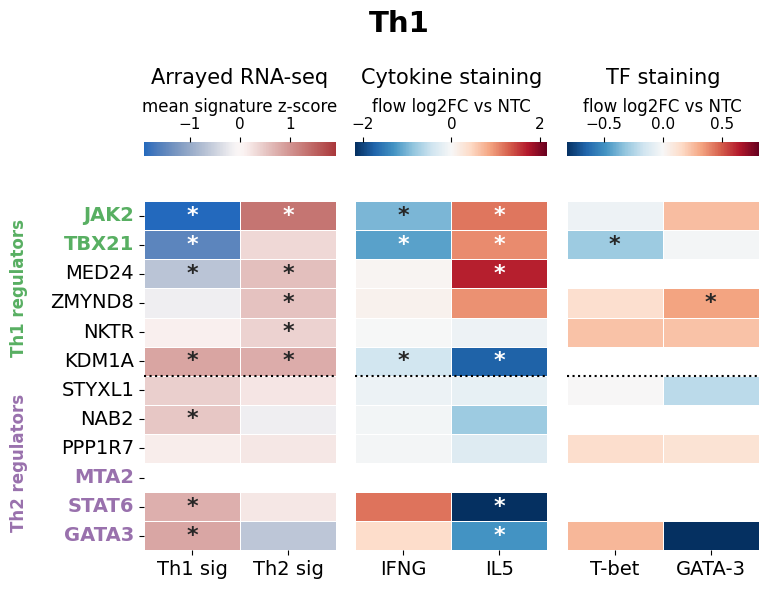

In [20]:

# Th1: bulk RNA-seq + cytokine + TF flow.
fig, axes = plot_heatmap_blocks(
    combined_summary,
    perturbations=plot_perturbations,
    blocks=[
        {
            'title': 'Arrayed RNA-seq',
            'measurements': bulk_columns('Th1'),
            'value_col': 'mean_zscore',
            'cmap': 'vlag',
            'cbar_label': 'mean signature z-score',
            'column_label_format': bulk_label,
        },
        {
            'title': 'Cytokine staining',
            'measurements': [
                ('IGG_Th1', 'IFNG'),
                ('IGG_Th1', 'IL5'),
            ],
            'value_col': 'mean_log2FC',
            'cmap': 'RdBu_r',
            'cbar_label': 'flow log2FC vs NTC',
            'column_label_format': lambda _c, m: m,
        },
        {
            'title': 'TF staining',
            'measurements': [
                ('TFRest_Th1', 'T-bet'),
                ('TFRest_Th1', 'GATA-3'),
            ],
            'value_col': 'mean_log2FC',
            'cmap': 'RdBu_r',
            'cbar_label': 'flow log2FC vs NTC',
            'column_label_format': lambda _c, m: m,
        },
    ],
    suptitle='Th1',
    cbar_loc='top',
    tick_fontsize=14,
    title_fontsize=15,
    cbar_fontsize=12,
    annot_fontsize=16,
    xlabel_fontsize=13,
    xtick_rotation=0,
)

style_regulator_axis(axes, plot_perturbations)

plt.show()

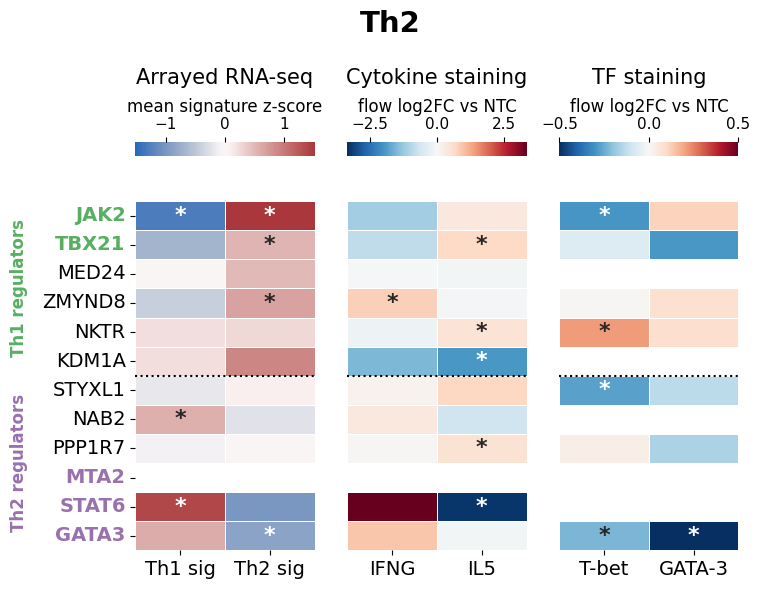

In [21]:
# Th2: bulk RNA-seq + cytokine + TF flow.
fig, axes = plot_heatmap_blocks(
    combined_summary,
    perturbations=plot_perturbations,
    blocks=[
        {
            'title': 'Arrayed RNA-seq',
            'measurements': bulk_columns('Th2'),
            'value_col': 'mean_zscore',
            'cmap': 'vlag',
            'cbar_label': 'mean signature z-score',
            'column_label_format': bulk_label,
        },
        {
            'title': 'Cytokine staining',
            'measurements': [
                ('IGG_Th2', 'IFNG'),
                ('IGG_Th2', 'IL5'),
            ],
            'value_col': 'mean_log2FC',
            'cmap': 'RdBu_r',
            'cbar_label': 'flow log2FC vs NTC',
            'column_label_format': lambda _c, m: m,
        },
        {
            'title': 'TF staining',
            'measurements': [
                ('TFRest_Th2', 'T-bet'),
                ('TFRest_Th2', 'GATA-3'),
            ],
            'value_col': 'mean_log2FC',
            'cmap': 'RdBu_r',
            'cbar_label': 'flow log2FC vs NTC',
            'column_label_format': lambda _c, m: m,
        },
    ],
    suptitle='Th2',
    cbar_loc='top',
    tick_fontsize=14,
    title_fontsize=15,
    cbar_fontsize=12,
    annot_fontsize=16,
    xlabel_fontsize=13,
    xtick_rotation=0,
)

style_regulator_axis(axes, plot_perturbations)

plt.show()

### Combined heatmap: all polarization conditions per measurement

One block per assay readout (Th1/Th2 signature, IFN-γ, IL-5, T-bet, GATA-3); within each block the three columns show the same readout across the three polarization conditions (non-polarized / Th1-polarized / Th2-polarized).

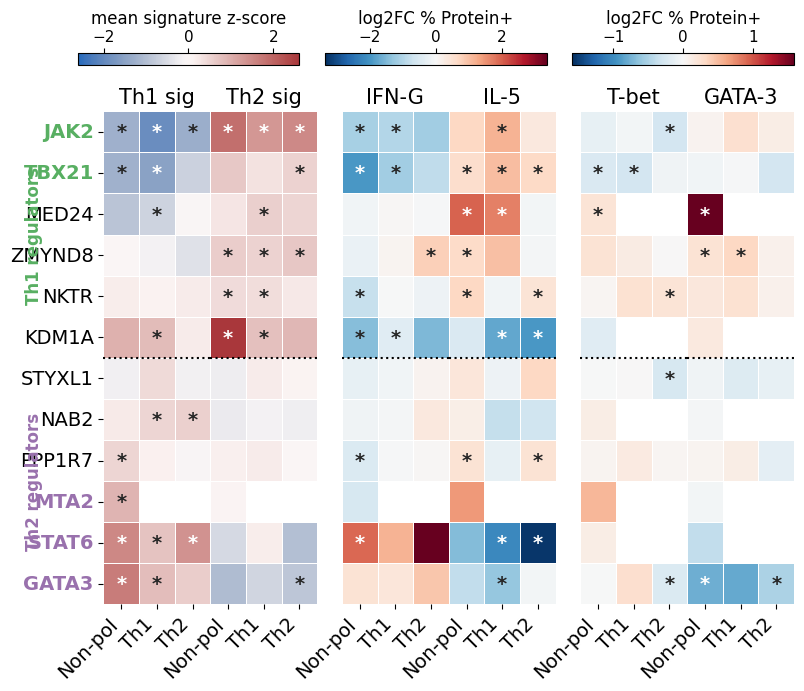

In [22]:
# Combined-conditions variant of the validation heatmap.
# Layout: one block per measurement (Th1 sig, Th2 sig, IFN-G, IL-5, T-bet,
# GATA-3); each block has 3 columns -- non-polarized / Th1 / Th2 -- so all
# polarization conditions for that readout sit together.
#
# Blocks are grouped via the `group` key into 3 supergroups, each with a
# single shared colorbar / vmin / vmax and no horizontal padding between
# blocks within the group:
#   - bulk        : Th1 sig + Th2 sig (mean signature z-score)
#   - cytokines   : IFN-G + IL-5      (flow log2FC vs NTC)
#   - tf          : T-bet + GATA-3    (flow log2FC vs NTC)
#
# Same row order (`plot_perturbations`) and Th1/Th2 group separator as
# the per-condition heatmaps above.

# Map a measurement-tuple (condition, measurement) to a short polarization
# label for the column tick. Bulk uses Th0/Th1/Th2 as the condition; flow
# encodes the polarization in the suffix of the condition string.
_POL_LABEL = {'Th0': 'Non-pol', 'Th1': 'Th1', 'Th2': 'Th2',
              'nonpolarized': 'Non-pol'}

def _polarization_label(cond, _meas):
    # Bulk: cond is 'Th0' / 'Th1' / 'Th2' -- use directly.
    if cond in _POL_LABEL:
        return _POL_LABEL[cond]
    # Flow: cond is e.g. 'IGG_Th1', 'TFRest_nonpolarized'. Strip the prefix.
    pol = cond.split('_', 1)[-1]
    return _POL_LABEL.get(pol, pol)

bulk_conditions = ['Th0', 'Th1', 'Th2']
igg_conditions  = ['IGG_nonpolarized', 'IGG_Th1', 'IGG_Th2']
tf_conditions   = ['TFRest_nonpolarized', 'TFRest_Th1', 'TFRest_Th2']

# Per-block width (inches) -- bulk blocks earn slightly more room than the
# flow blocks. Inter-group spacing is set via `group_gap` below.
BULK_BLOCK_W = 1.3
FLOW_BLOCK_W = 1.3

fig, axes = plot_heatmap_blocks(
    combined_summary,
    perturbations=plot_perturbations,
    blocks=[
        # --- Group: bulk RNA-seq (mean signature z-score) ---
        {
            'group': 'bulk',
            'title': 'Th1 sig',
            'measurements': [(c, 'bulk_Th1') for c in bulk_conditions],
            'p_col':'adj_p_value', 'star_threshold':0.1,
            'value_col': 'mean_zscore',
            'cmap': 'vlag',
            'cbar_label': 'mean signature z-score',
            'column_label_format': _polarization_label,
            'width': BULK_BLOCK_W,
        },
        {
            'group': 'bulk',
            'title': 'Th2 sig',
            'measurements': [(c, 'bulk_Th2') for c in bulk_conditions],
            'p_col':'adj_p_value', 'star_threshold':0.1,
            'value_col': 'mean_zscore',
            'cmap': 'vlag',
            'column_label_format': _polarization_label,
            'width': BULK_BLOCK_W,
        },
        # --- Group: cytokine staining (flow log2FC vs NTC) ---
        {
            'group': 'cytokines',
            'title': 'IFN-G',
            'measurements': [(c, 'IFNG') for c in igg_conditions],
            'p_col':'adj_p_value', 'star_threshold':0.1,
            'value_col': 'mean_log2FC',
            'cmap': 'RdBu_r',
            'cbar_label': 'log2FC % Protein+',
            'column_label_format': _polarization_label,
            'width': FLOW_BLOCK_W,
        },
        {
            'group': 'cytokines',
            'title': 'IL-5',
            'measurements': [(c, 'IL5') for c in igg_conditions],
            'p_col':'adj_p_value', 'star_threshold':0.1,
            'value_col': 'mean_log2FC',
            'cmap': 'RdBu_r',
            'column_label_format': _polarization_label,
            'width': FLOW_BLOCK_W,
        },
        # --- Group: TF staining (flow log2FC vs NTC) ---
        {
            'group': 'tf',
            'title': 'T-bet',
            'measurements': [(c, 'T-bet') for c in tf_conditions],
            'p_col':'adj_p_value', 'star_threshold':0.1,
            'value_col': 'mean_log2FC',
            'cmap': 'RdBu_r',
            'cbar_label': 'log2FC % Protein+',
            'column_label_format': _polarization_label,
            'width': FLOW_BLOCK_W,
        },
        {
            'group': 'tf',
            'title': 'GATA-3',
            'measurements': [(c, 'GATA-3') for c in tf_conditions],
            'p_col':'adj_p_value', 'star_threshold':0.1,
            'value_col': 'mean_log2FC',
            'cmap': 'RdBu_r',
            'column_label_format': _polarization_label,
            'width': FLOW_BLOCK_W,
        },
    ],
    suptitle=None,
    cbar_loc='top',
    group_gap=0.3,
    tick_fontsize=14,
    title_fontsize=15,
    cbar_fontsize=12,
    annot_fontsize=14,
    xlabel_fontsize=13,
    xtick_rotation=45,
)

style_regulator_axis(axes, plot_perturbations)
plt.savefig('./results/validation_summary.all_conditions.pdf')
plt.show()

In [23]:
# Save the list of regulators shown in the Th1/Th2 validation heatmaps.
# These are perturbation_order minus exclude_lowQ — same row order as the heatmaps.
out_path = '../../metadata/th1_th2_validation_heatmap_regulators.txt'
with open(out_path, 'w') as f:
    f.write('\n'.join(plot_perturbations) + '\n')
print(f'wrote {len(plot_perturbations)} regulators to {out_path}')

wrote 12 regulators to ../../metadata/th1_th2_validation_heatmap_regulators.txt


## Plot signature effects across conditions

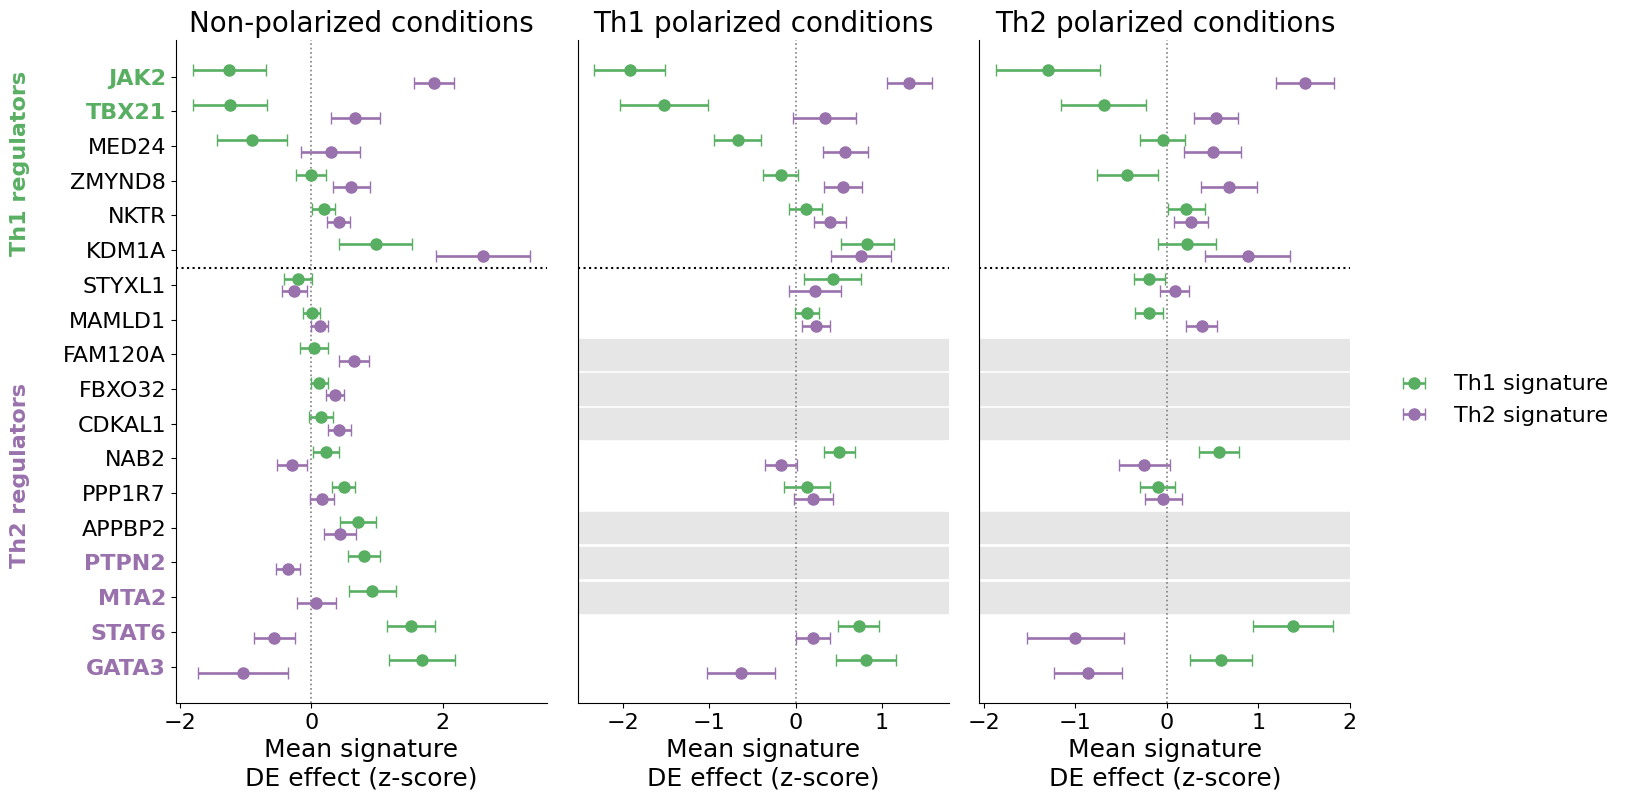

In [24]:
NOVEL_TARGETS = ['MED24', 'NKTR', 'ZMYND8', 'MAMLD1', 'STYXL1', "KDM1A",
                 'PPP1R7', 'NAB2', 'FBXO32', 'CDKAL1', 'FAM120A', 'APPBP2', 'MAMLD1']

SIG_COLORS = {
    'bulk_Th1': _palette['regulator_predictions']['negative'],  # Th1 signature
    'bulk_Th2': _palette['regulator_predictions']['positive'],  # Th2 signature
}
SIG_OFFSETS = {'bulk_Th1': -0.18, 'bulk_Th2': 0.18}
SIG_LABEL = {'bulk_Th1': 'Th1 signature', 'bulk_Th2': 'Th2 signature'}
MISSING_COLOR = '#e6e6e6'

# Increase font sizes for all elements
AXIS_LABEL_FONTSIZE = 18
TITLE_FONTSIZE = 20
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 16

# Local row order: keep Th1 / Th2 regulator groups separated (uses
# `predicted_class` from the heatmap section -- TBX21 pinned to Th1, GATA3
# to Th2, others by predicted Ota coefficient sign), and within each group
# sort by mean Th1-signature effect in Th0 (most-negative first, so the
# strongest Th1-suppressing regulators sit at the top of each block after
# the y-axis is inverted). Mirrors the row-order logic used for the
# heatmaps.
_th1_sort_key_th0 = (bulk_summary[(bulk_summary['condition'] == 'Th0')
                                  & (bulk_summary['measurement'] == 'bulk_Th1')]
                     .set_index('perturbation')['mean_zscore'])

def _sort_by_th1_effect_local(group):
    def k(t):
        v = _th1_sort_key_th0.get(t)
        return (-v) if (v is not None and pd.notna(v)) else float('inf')
    return sorted(group, key=k, reverse=True)

_th1_group = [t for t in perturbation_order if predicted_class(t) == 'Th1']
_th2_group = [t for t in perturbation_order if predicted_class(t) == 'Th2']
_neutral   = [t for t in perturbation_order if predicted_class(t) is None]

plot_order = (_sort_by_th1_effect_local(_th1_group)
              + _neutral
              + _sort_by_th1_effect_local(_th2_group))

conditions = ['Th0', 'Th1', 'Th2']
cond_labels = {
    'Th0': 'Non-polarized conditions',
    'Th1': 'Th1 polarized conditions',
    'Th2': 'Th2 polarized conditions',
}
fig, axes = plt.subplots(
    1, 3, sharey=True,
    figsize=(13, max(5.5, 0.45 * len(plot_order))),  # slightly larger default
)
y_pos = {t: i for i, t in enumerate(plot_order)}

for ax, cond in zip(axes, conditions):
    sub = bulk_summary[bulk_summary['condition'] == cond]

    # Mark rows with no data in this condition (both bulk_Th1 and bulk_Th2 missing).
    th1_present = set(sub.loc[sub['measurement'] == 'bulk_Th1', 'perturbation'].dropna())
    th2_present = set(sub.loc[sub['measurement'] == 'bulk_Th2', 'perturbation'].dropna())
    for t in plot_order:
        if t not in th1_present and t not in th2_present:
            i = y_pos[t]
            ax.axhspan(i - 0.45, i + 0.45, color=MISSING_COLOR, zorder=0)

    for meas in ['bulk_Th1', 'bulk_Th2']:
        s = (sub[sub['measurement'] == meas]
             .set_index('perturbation')
             .reindex(plot_order))
        ys = np.array([y_pos[t] for t in plot_order]) + SIG_OFFSETS[meas]
        ax.errorbar(
            s['mean_zscore'].values, ys,
            xerr=s['sem_zscore'].values,
            fmt='o', color=SIG_COLORS[meas], ecolor=SIG_COLORS[meas],
            elinewidth=1.9, capsize=4.5, markersize=8,
            label=SIG_LABEL[meas],
        )

    ax.axvline(0, color='grey', ls=':', lw=1.2, zorder=1)
    ax.set_title(cond_labels[cond], fontsize=TITLE_FONTSIZE)
    ax.set_xlabel('Mean signature\nDE effect (z-score)', fontsize=AXIS_LABEL_FONTSIZE)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='both', which='both', labelsize=TICK_FONTSIZE)

axes[0].set_yticks(range(len(plot_order)))
axes[0].set_yticklabels(plot_order, fontsize=TICK_FONTSIZE)
axes[0].invert_yaxis()  # match heatmap row order (top -> bottom)
for ax in axes[1:]:
    ax.tick_params(axis='y', left=False, labelleft=False)  # Only leftmost axis shows yticks

# Legend outside the rightmost subplot, vertically centred.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='center left', bbox_to_anchor=(0.93, 0.5),
    frameon=False, fontsize=LEGEND_FONTSIZE,
)
plt.tight_layout(rect=[0, 0, 0.93, 1])  # reserve right margin for legend

# Apply the same y-tick coloring + Th1/Th2 group annotation as the heatmap.
# Called after tight_layout so its subplots_adjust(left=...) isn't overridden.
# label_x is more conservative than the heatmap default because the forest
# panels are wider (axes coords scale with axis width).
style_regulator_axis(list(axes), plot_order,
                     label_x=-0.42, left_margin=0.01,
                     boundary_offset=-0.5,
                     fontsize=TICK_FONTSIZE)

plt.savefig('./results/validation_bulkRNAseq_signature.pdf')
plt.show()

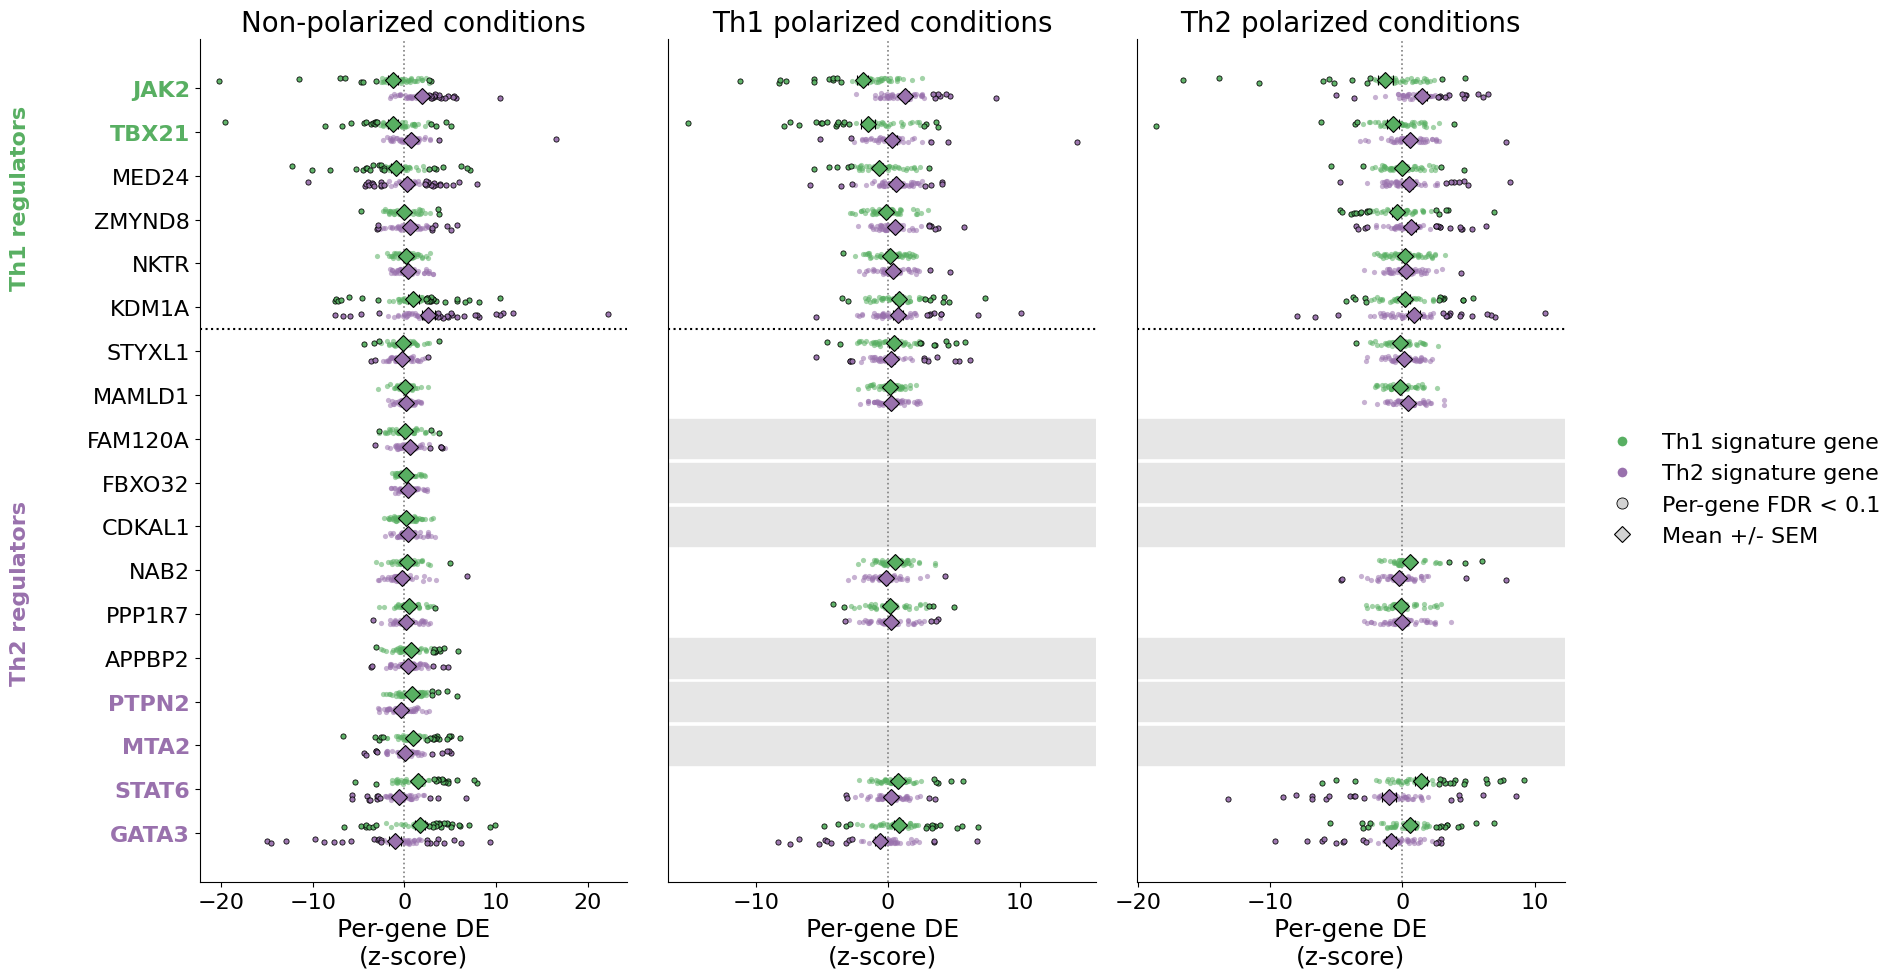

In [25]:
# Per-gene strip plot version of the Th1/Th2 signature forest plot.
# For each (perturbation, condition), shows:
#   - per-gene DE z-scores on Th1- and Th2-signature genes as a coloured strip
#   - a black outline on points significant at 10% FDR (per-gene padj < 0.1)
#   - mean +/- SEM as a larger diamond marker, matching the original forest plot
# Row order, group separator and y-tick styling reuse `plot_order`,
# `style_regulator_axis` and `predicted_class` from the heatmap section.
from matplotlib.lines import Line2D

JITTER_HALF = 0.06         # vertical jitter half-width for individual gene points
STRIP_SIZE = 14
STRIP_ALPHA = 0.55
SIG_OUTLINE_LW = 0.6

# Long-format per-gene z-scores on signature genes for the perturbations /
# conditions being plotted. `combined_de` is the per-gene DE table loaded above.
sig_genes_th1_dir = sig_down  # Th1 direction (most-negative Ota z)
sig_genes_th2_dir = sig_up    # Th2 direction
gene_to_meas = {g: 'bulk_Th1' for g in sig_genes_th1_dir}
gene_to_meas.update({g: 'bulk_Th2' for g in sig_genes_th2_dir})

per_gene = combined_de[
    combined_de['gene_name'].isin(set(gene_to_meas))
    & combined_de['target_contrast_gene_name'].isin(plot_order)
    & combined_de['condition'].isin(conditions)
].copy()
per_gene['measurement'] = per_gene['gene_name'].map(gene_to_meas)
per_gene['is_sig'] = per_gene['adj_p_value'] < 0.1

rng = np.random.default_rng(0)

fig, axes = plt.subplots(
    1, 3, sharey=True,
    figsize=(15, max(5.5, 0.55 * len(plot_order))),
)
y_pos = {t: i for i, t in enumerate(plot_order)}

for ax, cond in zip(axes, conditions):
    sub_summary = bulk_summary[bulk_summary['condition'] == cond]
    sub_pg = per_gene[per_gene['condition'] == cond]

    # Grey shading for rows missing in this condition (both signatures absent).
    th1_present = set(sub_summary.loc[sub_summary['measurement'] == 'bulk_Th1', 'perturbation'].dropna())
    th2_present = set(sub_summary.loc[sub_summary['measurement'] == 'bulk_Th2', 'perturbation'].dropna())
    for t in plot_order:
        if t not in th1_present and t not in th2_present:
            i = y_pos[t]
            ax.axhspan(i - 0.45, i + 0.45, color=MISSING_COLOR, zorder=0)

    for meas in ['bulk_Th1', 'bulk_Th2']:
        # Per-gene strip
        s_pg = sub_pg[sub_pg['measurement'] == meas]
        for t in plot_order:
            t_rows = s_pg[s_pg['target_contrast_gene_name'] == t]
            if t_rows.empty:
                continue
            yc = y_pos[t] + SIG_OFFSETS[meas]
            jitter = rng.uniform(-JITTER_HALF, JITTER_HALF, size=len(t_rows))
            ys = yc + jitter
            sig_mask = t_rows['is_sig'].values
            xs = t_rows['zscore'].values
            # Non-sig points: no edge.
            ax.scatter(xs[~sig_mask], ys[~sig_mask],
                       s=STRIP_SIZE, color=SIG_COLORS[meas], alpha=STRIP_ALPHA,
                       linewidths=0, zorder=2)
            # Sig points (per-gene padj < 0.1): black outline.
            ax.scatter(xs[sig_mask], ys[sig_mask],
                       s=STRIP_SIZE, color=SIG_COLORS[meas], alpha=0.95,
                       edgecolor='black', linewidth=SIG_OUTLINE_LW, zorder=3)

        # Mean +/- SEM marker (diamond, black-edged) overlaid on the strip.
        s = (sub_summary[sub_summary['measurement'] == meas]
             .set_index('perturbation')
             .reindex(plot_order))
        ys_summary = np.array([y_pos[t] for t in plot_order]) + SIG_OFFSETS[meas]
        ax.errorbar(
            s['mean_zscore'].values, ys_summary,
            xerr=s['sem_zscore'].values,
            fmt='D', mfc=SIG_COLORS[meas], mec='black', mew=0.8,
            ecolor='black', elinewidth=1.4, capsize=3.5, markersize=8,
            zorder=4,
        )

    ax.axvline(0, color='grey', ls=':', lw=1.2, zorder=1)
    ax.set_title(cond_labels[cond], fontsize=TITLE_FONTSIZE)
    ax.set_xlabel('Per-gene DE\n(z-score)', fontsize=AXIS_LABEL_FONTSIZE)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='both', which='both', labelsize=TICK_FONTSIZE)

axes[0].set_yticks(range(len(plot_order)))
axes[0].set_yticklabels(plot_order, fontsize=TICK_FONTSIZE)
axes[0].invert_yaxis()
for ax in axes[1:]:
    ax.tick_params(axis='y', left=False, labelleft=False)

# Legend
legend_elems = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=SIG_COLORS['bulk_Th1'],
           markersize=8, label='Th1 signature gene'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=SIG_COLORS['bulk_Th2'],
           markersize=8, label='Th2 signature gene'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgrey',
           markeredgecolor='black', markeredgewidth=SIG_OUTLINE_LW, markersize=8,
           label='Per-gene FDR < 0.1'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='lightgrey',
           markeredgecolor='black', markeredgewidth=0.8, markersize=8,
           label='Mean +/- SEM'),
]
fig.legend(handles=legend_elems, loc='center left',
           bbox_to_anchor=(0.93, 0.5), frameon=False, fontsize=LEGEND_FONTSIZE)
plt.tight_layout(rect=[0, 0, 0.93, 1])

style_regulator_axis(list(axes), plot_order,
                     label_x=-0.42, left_margin=0.01,
                     boundary_offset=-0.5,
                     fontsize=TICK_FONTSIZE)

plt.savefig('./results/validation_bulkRNAseq_signature.per_gene.pdf')
plt.show()

## 4. Cross-target DE effects

For each perturbed gene (rows), show its bulk DE effect on every other
perturbed gene (columns). Colour = DESeq2 `zscore` (per-gene t-statistic
divided by an internal scale; positive = upregulated under KD); star =
`adj_p_value < 0.05`. One panel per condition. The diagonal reports each
KD’s self-effect and is therefore the strongest signal in every panel.


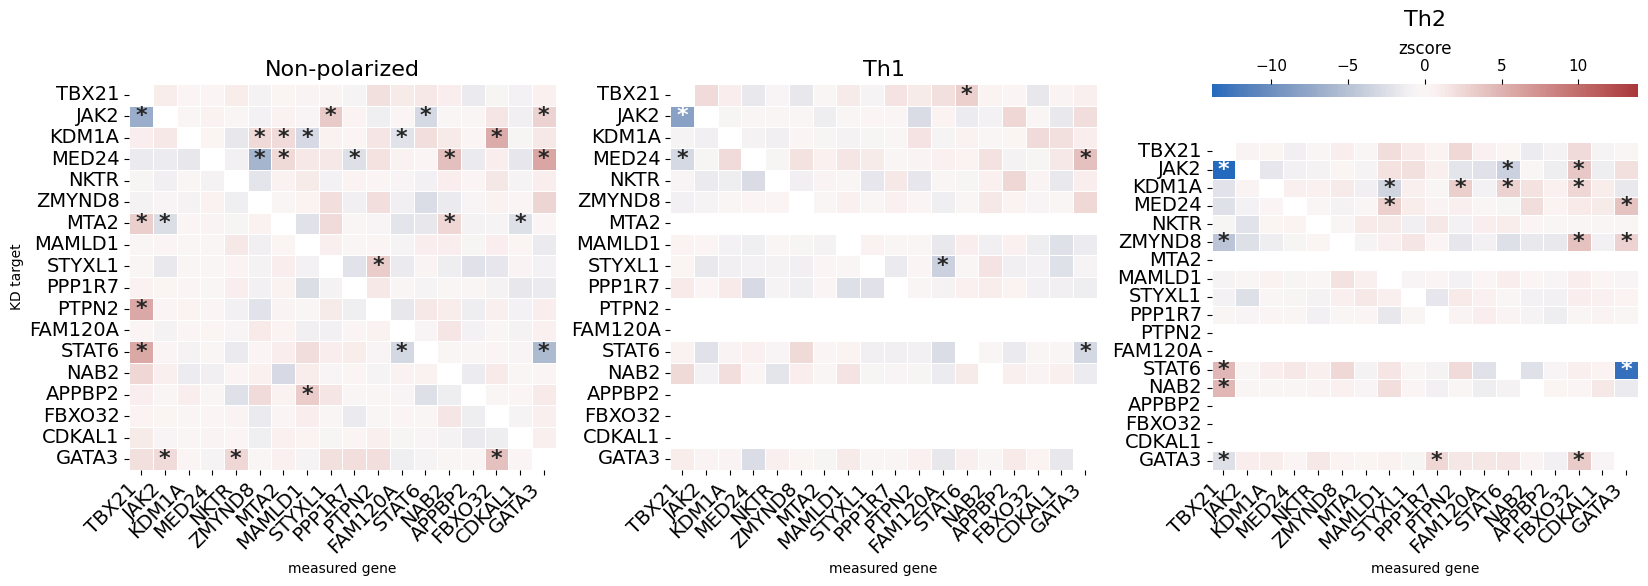

In [26]:
# Cross-target effect heatmap: rows = KD target, columns = measured perturbed
# gene, color = zscore, star = adj_p_value < 0.05. Uses combined_de (already
# deduplicated against Diff081/Diff084 overlap in the bulk-run cell).
# Use the shared perturbation_order (TBX21 top, GATA3 bottom, middle
# sorted by predicted Th2-vs-Th1 effect) for both rows and columns so
# this heatmap aligns with the section 3/4 panels.
all_de_targets = set(combined_de['target_contrast_gene_name'].dropna())
all_targets = [t for t in perturbation_order if t in all_de_targets]

cross_summary = (
    combined_de[combined_de['gene_name'].isin(all_targets)]
    .rename(columns={
        'target_contrast_gene_name': 'perturbation',
        'gene_name': 'measurement',
        'zscore': 'mean_zscore',
        'log_fc': 'mean_log2FC',
    })
    [['perturbation', 'condition', 'measurement',
      'mean_zscore', 'mean_log2FC', 'p_value', 'adj_p_value']]
)
# Mask self-effects (diagonal): each KD's effect on its own gene dominates
# the colour scale and isn't informative for cross-target signal.
cross_summary = cross_summary[cross_summary['perturbation'] != cross_summary['measurement']]

# Symmetric color limits across all panels so signs are comparable.
absmax = float(np.nanmax(np.abs(cross_summary['mean_zscore'])))

conditions = ['Th0', 'Th1', 'Th2']
CONDITION_LABEL = {'Th0': 'Non-polarized', 'Th1': 'Th1', 'Th2': 'Th2'}
fig, axes = plt.subplots(
    1, len(conditions),
    figsize=(0.27 * len(all_targets) * len(conditions) + 2,
             0.22 * len(all_targets) + 2),
    sharey=False,
)
for i, (ax, cond) in enumerate(zip(axes, conditions)):
    plot_heatmap(
        cross_summary, ax=ax,
        perturbations=all_targets,
        measurements=[(cond, g) for g in all_targets],
        value_col='mean_zscore', p_col='adj_p_value', star_threshold=0.1,
        cmap='vlag', vmin=-absmax, vmax=absmax,
        cbar=(i == len(conditions) - 1),
        cbar_label='zscore',
        yticklabels=True,
        column_label_format=lambda _c, m: m,
        title=CONDITION_LABEL[cond],
    )
    ax.set_xlabel('measured gene')

axes[0].set_ylabel('KD target')
plt.tight_layout()
plt.show()


## FACS effect summary

/tmp/ipykernel_3131714/2894784175.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.97, 0.97])


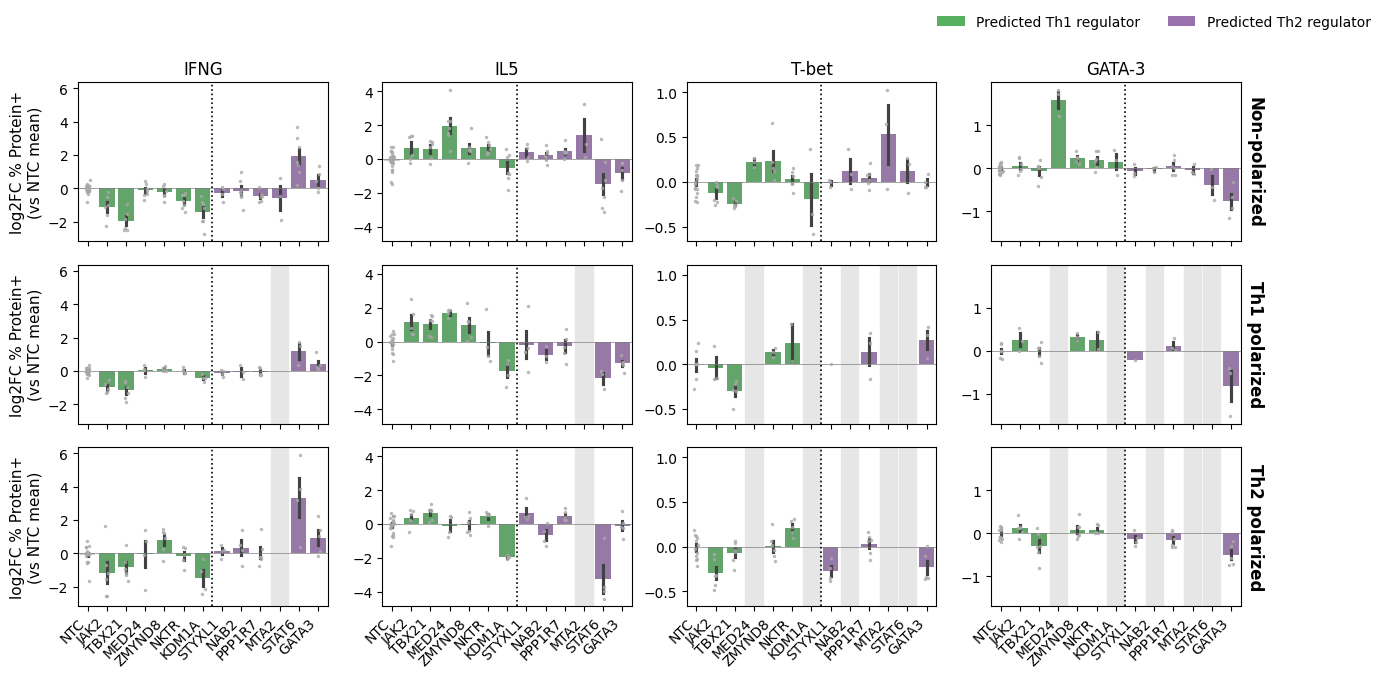

In [27]:
# FACS log2FC summary figure (placed at the bottom so it can reuse
# plot_perturbations, predicted_class, TH1_COLOR, TH2_COLOR, CONTROL_COLOR
# and th1_th2_boundary from the heatmap cell). Bars: one per perturbation
# on the x-axis -- NTCs collapsed and pinned leftmost, regulators in the
# main heatmap row order. y-axis is log2FC vs NTC. Columns = stained
# protein; rows = polarization condition. Bars are coloured by the
# regulator's predicted Th1/Th2 class. A dotted vertical line marks the
# Th1 vs Th2 boundary in each panel. Perturbations with no data in a
# given panel are shaded grey (matching the bulk-RNA-seq dot plot).
import matplotlib.patches as mpatches

NTC_NAMES = ('NTC1', 'NTC2', 'NTC')
MISSING_COLOR = '#e6e6e6'

def _bar_color(target):
    if target == 'NTC':
        return CONTROL_COLOR
    cls = predicted_class(target)
    if cls == 'Th1':
        return TH1_COLOR
    if cls == 'Th2':
        return TH2_COLOR
    return CONTROL_COLOR

pl = flow_lfc.copy()
pl['perturbation_label'] = pl['perturbation'].replace({n: 'NTC' for n in NTC_NAMES})
# Heatmap-sorted regulator order (excludes lowQ; sorted within Th1/Th2 groups);
# NTC pinned to the leftmost slot.
x_order = ['NTC'] + list(plot_perturbations)
pl = pl[pl['perturbation_label'].isin(x_order)].copy()
pl['polarization'] = (pl['condition'].str.replace(r'^(IGG|TFRest)_', '', regex=True)
                                       .replace({'nonpolarized': 'Non-polarized'})
                                       .replace({'Th1': 'Th1 polarized'})
                                       .replace({'Th2': 'Th2 polarized'})
                                       )

measurements_to_plot = ['IFNG', 'IL5', 'T-bet', 'GATA-3']
pol_order = ['Non-polarized', 'Th1 polarized', 'Th2 polarized']
palette = {t: _bar_color(t) for t in x_order}

# Th1/Th2 boundary: th1_th2_boundary returns the first-Th2 index in
# plot_perturbations. NTC sits at x=0, so the first regulator is at x=1;
# the line goes between the last Th1 (x = boundary) and the first Th2
# (x = boundary + 1) -- i.e. at boundary + 0.5.
_boundary = th1_th2_boundary(plot_perturbations) + 0.5

n_pert, n_meas, n_pol = len(x_order), len(measurements_to_plot), len(pol_order)
fig, axes = plt.subplots(
    n_pol, n_meas,
    figsize=(n_meas * (0.25 * n_pert + 0.5), n_pol * 2.0 + 0.8),
    sharex=True, sharey='col', squeeze=False,
    gridspec_kw={'wspace': 0.22, 'hspace': 0.15},
)

def _shade_missing(ax, sub):
    """Grey out x-positions for perturbations absent from `sub`."""
    present = set(sub['perturbation_label'].dropna()) if not sub.empty else set()
    for xi, t in enumerate(x_order):
        if t not in present:
            ax.axvspan(xi - 0.45, xi + 0.45, color=MISSING_COLOR, zorder=0)

for r, pol in enumerate(pol_order):
    for c, meas in enumerate(measurements_to_plot):
        ax = axes[r, c]
        sub = pl[(pl['measurement'] == meas) & (pl['polarization'] == pol)]
        # Always set the x-axis to the full perturbation order so the grey
        # shading lines up with the bar slots even when sub is empty or
        # only covers a subset of perturbations.
        ax.set_xlim(-0.5, len(x_order) - 0.5)
        ax.set_xticks(range(len(x_order)))
        ax.set_xticklabels(x_order)
        _shade_missing(ax, sub)
        if sub.empty:
            ax.text(0.5, 0.5, 'no data', transform=ax.transAxes,
                    ha='center', va='center', color='grey', fontsize=9)
            ax.set_yticks([])
            if r == 0:
                ax.set_title(meas, fontsize=12)
            if c == 0:
                ax.set_ylabel('log2FC % Protein+\n(vs NTC mean)', fontsize=11)
            else:
                ax.set_ylabel('')
            ax.set_xlabel('')
            continue
        sns.barplot(
            data=sub, x='perturbation_label', y='log2FC',
            order=x_order, hue='perturbation_label', palette=palette,
            errorbar='se', ax=ax, legend=False,
        )
        sns.stripplot(
            data=sub, x='perturbation_label', y='log2FC',
            order=x_order, color='darkgrey', size=2.5, alpha=0.8, ax=ax,
        )
        ax.axhline(0, color='grey', lw=0.5)
        ax.axvline(_boundary, color='black', linestyle=':', linewidth=1.2)
        if r == 0:
            ax.set_title(meas, fontsize=12)
        if c == 0:
            ax.set_ylabel('log2FC % Protein+\n(vs NTC mean)', fontsize=11)
        else:
            ax.set_ylabel('')
        ax.set_xlabel('')

for ax in axes[-1, :]:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Polarization condition annotated on the right edge of each row.
for r, pol in enumerate(pol_order):
    axes[r, -1].text(1.02, 0.5, pol, transform=axes[r, -1].transAxes,
                     rotation=270, va='center', ha='left',
                     fontsize=12, fontweight='bold')

legend_elems = [
    mpatches.Patch(facecolor=TH1_COLOR, label='Predicted Th1 regulator'),
    mpatches.Patch(facecolor=TH2_COLOR, label='Predicted Th2 regulator'),
    # mpatches.Patch(facecolor=CONTROL_COLOR, label='Control'),
    # mpatches.Patch(facecolor=MISSING_COLOR, label='No data'),
]
fig.legend(handles=legend_elems, loc='upper right',
           bbox_to_anchor=(0.995, 0.998), frameon=False, ncol=4)

plt.tight_layout(rect=[0, 0, 0.97, 0.97])
plt.show()

In [28]:
combined_summary[combined_summary['perturbation'] == 'TBX21']

,perturbation,condition,measurement,n,mean_log2FC,mean_zscore,sem_zscore,p_value,adj_p_value,n_ntc
37,TBX21,Th0,bulk_Th2,50,0.180119,0.666265,0.372526,0.079878,0.126473,NaN
38,TBX21,Th1,bulk_Th2,50,0.056216,0.335387,0.367922,0.366457,0.401953,NaN
39,TBX21,Th2,bulk_Th2,50,0.134994,0.538862,0.240415,0.029564,0.076453,NaN
80,TBX21,Th0,bulk_Th1,48,-0.213599,-1.239040,0.559436,0.031658,0.075187,NaN
81,TBX21,Th1,bulk_Th1,47,-0.399478,-1.520491,0.511308,0.004672,0.018688,NaN
82,TBX21,Th2,bulk_Th1,48,-0.113466,-0.689465,0.461988,0.142280,0.341473,NaN
194,TBX21,IGG_Th1,IFNG,6,-1.170616,NaN,NaN,0.002455,0.014733,11.0
195,TBX21,IGG_Th1,IL5,6,1.030809,NaN,NaN,0.005593,0.016779,11.0
196,TBX21,IGG_Th2,IFNG,6,-0.845236,NaN,NaN,0.064120,0.181618,12.0
197,TBX21,IGG_Th2,IL5,6,0.670690,NaN,NaN,0.005197,0.031183,12.0


In [29]:

# Compare p-values from t-test on per-gene zscore vs log2FC for the Th1/Th2 signature test.
# bulk_summary already exists (uses zscore). Re-run with test_col='log_fc'.

bulk_summary_lfc = summarize_signature_effect(
    combined_de, sig_up_genes=sig_up, sig_down_genes=sig_down,
    test_col='log_fc',
)

cmp = (bulk_summary[['perturbation', 'condition', 'measurement', 'p_value', 'adj_p_value']]
       .rename(columns={'p_value': 'p_z', 'adj_p_value': 'padj_z'})
       .merge(
           bulk_summary_lfc[['perturbation', 'condition', 'measurement', 'p_value', 'adj_p_value']]
           .rename(columns={'p_value': 'p_lfc', 'adj_p_value': 'padj_lfc'}),
           on=['perturbation', 'condition', 'measurement']))

import numpy as np
cmp['log10_p_z']    = -np.log10(cmp['p_z'].clip(lower=1e-300))
cmp['log10_p_lfc']  = -np.log10(cmp['p_lfc'].clip(lower=1e-300))
cmp['log10_padj_z']   = -np.log10(cmp['padj_z'].clip(lower=1e-300))
cmp['log10_padj_lfc'] = -np.log10(cmp['padj_lfc'].clip(lower=1e-300))

# Overall correlation between -log10 p-values from the two tests
from scipy.stats import pearsonr, spearmanr
mask = cmp[['log10_p_z', 'log10_p_lfc']].notna().all(axis=1)
print(f'n contrasts compared: {mask.sum()}')
print(f'Pearson r  (-log10 p):     {pearsonr(cmp.loc[mask, "log10_p_z"], cmp.loc[mask, "log10_p_lfc"])[0]:.3f}')
print(f'Spearman r (-log10 p):     {spearmanr(cmp.loc[mask, "log10_p_z"], cmp.loc[mask, "log10_p_lfc"])[0]:.3f}')

# Significance-call agreement at adj p < 0.1
sig_z   = cmp['padj_z']   < 0.1
sig_lfc = cmp['padj_lfc'] < 0.1
print(f'\nSignificance calls @ adj p<0.1:')
print(f'  z-score test:  {sig_z.sum()} sig')
print(f'  log2FC test:   {sig_lfc.sum()} sig')
print(f'  agreement:     {(sig_z == sig_lfc).mean():.1%}')
print(f'  sig in z only: {(sig_z & ~sig_lfc).sum()}')
print(f'  sig in lfc only: {(sig_lfc & ~sig_z).sum()}')

# Largest disagreements
cmp['delta_log10_p'] = cmp['log10_p_z'] - cmp['log10_p_lfc']
print('\nTop 10 contrasts where z-score gives MUCH stronger p-value:')
print(cmp.nlargest(10, 'delta_log10_p')[['perturbation','condition','measurement','p_z','p_lfc']].to_string(index=False))
print('\nTop 10 contrasts where log2FC gives MUCH stronger p-value:')
print(cmp.nsmallest(10, 'delta_log10_p')[['perturbation','condition','measurement','p_z','p_lfc']].to_string(index=False))


n contrasts compared: 86
Pearson r  (-log10 p):     0.858
Spearman r (-log10 p):     0.654

Significance calls @ adj p<0.1:
  z-score test:  34 sig
  log2FC test:   19 sig
  agreement:     77.9%
  sig in z only: 17
  sig in lfc only: 2

Top 10 contrasts where z-score gives MUCH stronger p-value:
perturbation condition measurement      p_z    p_lfc
      FBXO32       Th0    bulk_Th2 0.011363 0.721440
        JAK2       Th1    bulk_Th2 0.000006 0.000385
        NKTR       Th0    bulk_Th2 0.022760 0.864982
      MAMLD1       Th2    bulk_Th2 0.029254 0.618955
      ZMYND8       Th1    bulk_Th2 0.017056 0.294570
       KDM1A       Th1    bulk_Th2 0.033706 0.510761
       STAT6       Th1    bulk_Th1 0.003374 0.045258
        NAB2       Th1    bulk_Th1 0.008268 0.109184
       KDM1A       Th1    bulk_Th1 0.009574 0.099039
     FAM120A       Th0    bulk_Th2 0.006158 0.059815

Top 10 contrasts where log2FC gives MUCH stronger p-value:
perturbation condition measurement          p_z        p_lfc

In [30]:

# Clean up scratch variables from the log2FC vs zscore comparison.
for _v in ['bulk_summary_lfc', 'cmp', 'sig_z', 'sig_lfc', 'mask']:
    if _v in globals():
        del globals()[_v]
print('cleaned up; bulk_summary unchanged (still uses zscore-based p-values).')


cleaned up; bulk_summary unchanged (still uses zscore-based p-values).


In [31]:

# Pull the summary rows for MED24 vs Th1 sig and NKTR vs Th2 sig across all conditions.
import numpy as np
sub = bulk_summary[
    ((bulk_summary['perturbation'] == 'MED24') & (bulk_summary['measurement'] == 'bulk_Th1'))
    | ((bulk_summary['perturbation'] == 'NKTR') & (bulk_summary['measurement'] == 'bulk_Th2'))
].copy()
print(sub.to_string(index=False))


perturbation condition measurement  n  mean_log2FC  mean_zscore  sem_zscore  p_value  adj_p_value
        NKTR       Th0    bulk_Th2 50     0.007903     0.416352    0.177054 0.022760     0.072073
        NKTR       Th1    bulk_Th2 50     0.055619     0.396699    0.184370 0.036381     0.087313
        NKTR       Th2    bulk_Th2 50     0.015732     0.260421    0.186041 0.167872     0.223830
       MED24       Th0    bulk_Th1 48    -0.167528    -0.900017    0.532934 0.097883     0.169071
       MED24       Th1    bulk_Th1 47    -0.255185    -0.669894    0.267452 0.015861     0.031721
       MED24       Th2    bulk_Th1 48    -0.078568    -0.046172    0.250752 0.854699     0.854699


In [32]:

# Side-by-side: MED24 vs Th1 signature, NKTR vs Th2 signature, all conditions.
import numpy as np
rows = bulk_summary[
    ((bulk_summary['perturbation'] == 'MED24') & (bulk_summary['measurement'] == 'bulk_Th1'))
    | ((bulk_summary['perturbation'] == 'NKTR') & (bulk_summary['measurement'] == 'bulk_Th2'))
].copy()
rows = rows.sort_values(['perturbation', 'condition'])
print(rows[['perturbation','condition','measurement','n','mean_zscore','sem_zscore','p_value','adj_p_value']].to_string(index=False))


perturbation condition measurement  n  mean_zscore  sem_zscore  p_value  adj_p_value
       MED24       Th0    bulk_Th1 48    -0.900017    0.532934 0.097883     0.169071
       MED24       Th1    bulk_Th1 47    -0.669894    0.267452 0.015861     0.031721
       MED24       Th2    bulk_Th1 48    -0.046172    0.250752 0.854699     0.854699
        NKTR       Th0    bulk_Th2 50     0.416352    0.177054 0.022760     0.072073
        NKTR       Th1    bulk_Th2 50     0.396699    0.184370 0.036381     0.087313
        NKTR       Th2    bulk_Th2 50     0.260421    0.186041 0.167872     0.223830


## 5. Validation summary supplementary table

One row per `(target_name, condition)` combining bulk RNA-seq signature scores,
FACS log2FC summaries, and perturb-seq cross-guide / cross-donor robustness
metrics. NTC rows are kept separately per batch as a data-availability check.
Saved to `metadata/suppl_tables/Th1Th2_validation_summary.suppl_table.csv`.

In [33]:
# Reload bulk-RNA-seq sample metadata so we can count donors per
# (perturbation, condition) for the supplementary table. This mirrors the
# loaders in bulkRNAseq_analysis.ipynb but only keeps the per-sample
# (batch, donor, condition, perturbation_group) tuple needed here.
import os

GUIDE_TO_TARGET = {
    'M-24':    'MED24',     'KD-1':    'KDM1A',
    'PT-2':    'PTPN2',     'F-32-2':  'FBXO32',
    'F-32-3':  'FBXO32-3',  'AP-2-2':  'APPBP2',
    'F120A':   'FAM120A',   'F120A-1': 'FAM120A',
    'CDK1-1':  'CDKAL1',    'CDK-1-1': 'CDKAL1',
    'STAT6':   'STAT6',     'STAT6-1': 'STAT6',
    'NTChe':   'NTC',       'MTA2':    'MTA2',
    'TBX21':   'TBX21',     'GATA3':   'GATA3',
    'JAK2':    'JAK2',
}

def _load_polarized_meta(batch, data_root, experiments):
    parts = []
    for cond, info in experiments.items():
        meta = pd.read_csv(f"{data_root}/{info['meta']}", encoding='utf-8-sig')
        meta = meta.loc[:, ~meta.columns.str.match(r'^Unnamed')]
        meta.columns = [c.strip() for c in meta.columns]
        meta['donor'] = meta['sample_name'].str.split('_').str[0]
        meta['perturbation'] = meta['sample_name'].str.split('_').str[1]
        meta['condition'] = cond
        meta['batch'] = batch
        meta['Flag'] = meta['Flag'].astype(str).str.upper() == 'TRUE'
        parts.append(meta[['donor','perturbation','condition','batch','Flag']])
    return pd.concat(parts, ignore_index=True)

def _load_diff081_meta():
    sn = pd.read_csv('/mnt/oak/users/emma/data/GWT/PDKJK2_results/PDKJK2-mapping-stats-reads.csv',
                     usecols=[0], header=None, skiprows=1)[0].values
    m = pd.DataFrame({'sample_name': sn})
    m['donor'] = m['sample_name'].str.split('_').str[0]
    m['perturbation'] = m['sample_name'].str.split('_', n=1).str[1]
    m['condition'] = 'Th0'
    m['batch'] = 'Diff081'
    m['Flag'] = False
    return m[['donor','perturbation','condition','batch','Flag']]

bulk_meta = pd.concat([
    _load_diff081_meta(),
    _load_polarized_meta('Diff084', '/mnt/oak/users/emma/data/GWT/Diff084bulkRNAseq', {
        'Th0': {'meta': 'Diff084_Day12_nonpolarized_FMZ494_sample_name.csv'},
        'Th1': {'meta': 'Diff084_Day12_Th1_P567SY_sample_name.csv'},
        'Th2': {'meta': 'Diff084_Day12_Th2_NM89Y9_sample_name.csv'},
    }),
    _load_polarized_meta('Diff089', '/mnt/oak/users/emma/data/GWT/Diff089bulkRNAseq', {
        'Th0': {'meta': 'Diff089Day12_nonpolarized_BT2R52_sample_name.csv'},
        'Th1': {'meta': 'Diff089Day12_Th1_JVCNWP_sample_name.csv'},
        'Th2': {'meta': 'Diff089Day12_Th2_MNX6KK_sample_name.csv'},
    }),
], ignore_index=True)

# Drop flagged samples to match the DE-input cohort.
bulk_meta = bulk_meta[~bulk_meta['Flag']].copy()

# Harmonise perturbation labels: gene-level for Diff081, NTC* -> NTC.
def _harmonise(p, b):
    if isinstance(p, str) and p.startswith('NTC'):
        return 'NTC'
    return GUIDE_TO_TARGET.get(p, p) if b == 'Diff081' else p
bulk_meta['perturbation_group'] = [
    _harmonise(p, b) for p, b in zip(bulk_meta['perturbation'], bulk_meta['batch'])
]
print(f'bulk_meta: {bulk_meta.shape}')
display(bulk_meta.head())


bulk_meta: (290, 6)


,donor,perturbation,condition,batch,Flag,perturbation_group
0,D1,TBX21,Th0,Diff081,False,TBX21
1,D1,GATA3,Th0,Diff081,False,GATA3
2,D1,M-24,Th0,Diff081,False,MED24
3,D1,KD-1,Th0,Diff081,False,KDM1A
4,D1,PT-2,Th0,Diff081,False,PTPN2


In [34]:
# Build validation_summary: one row per (target_name, condition).
# Bulk fields come from `bulk_summary` (mean signature z / sem / pvals)
# and `combined_de` (batch list + donor counts). FACS fields come from
# `flow_summary` (per-protein log2FC / pval / FDR) and `flow_lfc` (NTC
# rows aggregated per batch). Cross-guide and cross-donor metrics come
# from the perturb-seq robustness tables (matched on `target_name`,
# Stim8hr -- there is no Th1/Th2 perturb-seq counterpart).

CONDITION_LABEL = {
    'Th0': 'Non-polarized',
    'Th1': 'Th1-polarized',
    'Th2': 'Th2-polarized',
}
FACS_PROTEINS = ['IFNG', 'IL5', 'T-bet', 'GATA-3']
# Column-safe names (no dashes) used in the output table.
FACS_COL = {'IFNG': 'IFNG', 'IL5': 'IL5', 'T-bet': 'Tbet', 'GATA-3': 'GATA3'}
NTC_NAMES = ('NTC1', 'NTC2', 'NTC')

# Map flow `condition` strings (e.g. 'IGG_Th1', 'TFRest_nonpolarized')
# to the matching bulk condition.
def _flow_pol(s):
    pol = s.split('_', 1)[-1]
    return {'nonpolarized': 'Th0', 'Th1': 'Th1', 'Th2': 'Th2'}.get(pol, pol)

# --- Bulk donor counts + batch list per (perturbation, condition) ---
bulk_donors = (bulk_meta
               .groupby(['perturbation_group', 'condition'])['donor']
               .nunique().rename('bulkRNA_n_donors').reset_index()
               .rename(columns={'perturbation_group': 'target_name'}))
bulk_batches = (bulk_meta
                .groupby(['perturbation_group', 'condition'])['batch']
                .agg(lambda s: ','.join(sorted(set(s)))).rename('bulkRNA_batch').reset_index()
                .rename(columns={'perturbation_group': 'target_name'}))

# --- Bulk Th1/Th2 signature stats (pivot bulk_summary on measurement) ---
bulk_long = bulk_summary.rename(columns={'perturbation': 'target_name'})
bulk_pivot_pieces = []
for direction, suffix in [('bulk_Th1', 'Th1'), ('bulk_Th2', 'Th2')]:
    sub = bulk_long[bulk_long['measurement'] == direction][
        ['target_name', 'condition', 'mean_zscore', 'sem_zscore', 'p_value', 'adj_p_value']
    ].rename(columns={
        'mean_zscore':  f'bulkRNA_{suffix}_mean_zscore',
        'sem_zscore':   f'bulkRNA_{suffix}_sem_zscore',
        'p_value':      f'bulkRNA_{suffix}_pvalue',
        'adj_p_value':  f'bulkRNA_{suffix}_adj_pvalue',
    })
    bulk_pivot_pieces.append(sub.set_index(['target_name', 'condition']))
bulk_pivot = pd.concat(bulk_pivot_pieces, axis=1).reset_index()

# --- FACS log2FC / p / FDR per protein, pivoted to one column per protein ---
flow_pieces = []
flow = flow_summary.copy()
flow['cond_short'] = flow['condition'].map(_flow_pol)
flow = flow.rename(columns={'perturbation': 'target_name'})
for prot in FACS_PROTEINS:
    col = FACS_COL[prot]
    sub = flow[flow['measurement'] == prot][
        ['target_name', 'cond_short', 'mean_log2FC', 'p_value', 'adj_p_value']
    ].rename(columns={
        'cond_short':   'condition',
        'mean_log2FC':  f'flow_{col}_log2FC',
        'p_value':      f'flow_{col}_pval',
        'adj_p_value':  f'flow_{col}_fdr',
    })
    flow_pieces.append(sub.set_index(['target_name', 'condition']))
flow_pivot = pd.concat(flow_pieces, axis=1).reset_index()
# Flow batch is constant (Diff084); record explicitly so NTC rows below
# can use a different value if needed.
flow_pivot['flow_batch'] = 'Diff084'

# --- Perturb-seq robustness metrics (Stim8hr only -- no Th1/Th2 counterpart) ---
xguide = pd.read_csv('../../metadata/DE_by_guide.correlation_results.csv')
xguide = xguide[xguide['culture_condition'] == 'Stim8hr'][
    ['target', 'correlation_signif', 'n_signif_ontarget']
].rename(columns={
    'target': 'target_name',
    'correlation_signif': 'pseq_crossguide_corr_signif',
    'n_signif_ontarget': 'pseq_crossguide_n_signif_ontarget',
})

xdonor = pd.read_csv('../3_DE_analysis/results/DE_donor_robustness_correlation_summary.csv')
xdonor = xdonor[xdonor['condition'] == 'Stim8hr'][
    ['target_name', 'donor_correlation_hits_mean']
].rename(columns={
    'donor_correlation_hits_mean': 'pseq_crossdonor_corr_hits_mean',
})

# Number of DE genes per perturbation in perturb-seq (Stim8hr). Matched on
# target gene name; one row per gene in this condition.
de_stats = pd.read_csv('../../metadata/suppl_tables/DE_stats.suppl_table.csv')
de_stats = de_stats[de_stats['culture_condition'] == 'Stim8hr'][
    ['target_contrast_gene_name', 'n_total_de_genes']
].rename(columns={
    'target_contrast_gene_name': 'target_name',
    'n_total_de_genes': 'pseq_n_total_de_genes',
})

# --- Assemble non-NTC rows: outer-join bulk and FACS, then attach robustness ---
non_ntc_targets = sorted(set(bulk_pivot['target_name']) | set(flow_pivot['target_name']))
non_ntc_targets = [t for t in non_ntc_targets if t not in ('NTC', 'FBXO32-3')]  # FBXO32-3 is the alt FBXO32 guide (excluded, same as in heatmaps)
conditions = ['Th0', 'Th1', 'Th2']
scaffold = pd.DataFrame(
    [(t, c) for t in non_ntc_targets for c in conditions],
    columns=['target_name', 'condition'],
)
summary = (scaffold
           .merge(bulk_batches, on=['target_name', 'condition'], how='left')
           .merge(bulk_donors, on=['target_name', 'condition'], how='left')
           .merge(bulk_pivot, on=['target_name', 'condition'], how='left')
           .merge(flow_pivot, on=['target_name', 'condition'], how='left')
           .merge(xguide, on='target_name', how='left')
           .merge(xdonor, on='target_name', how='left')
           .merge(de_stats, on='target_name', how='left'))

# --- NTC rows: one per (NTC label, batch, condition) ---
# Bulk NTCs: counts from bulk_meta (perturbation_group=='NTC'), keep per-batch.
ntc_bulk = (bulk_meta[bulk_meta['perturbation_group'] == 'NTC']
            .groupby(['batch', 'condition'])
            .agg(bulkRNA_n_donors=('donor', 'nunique'))
            .reset_index()
            .rename(columns={'batch': 'bulkRNA_batch'}))
ntc_bulk['target_name'] = 'NTC'
# FACS NTCs: aggregate flow_lfc rows where perturbation is one of NTC_NAMES.
# Each NTC sample has a log2FC against its donor's NTC mean (~0 by
# construction); we report the mean across donors per (batch, condition,
# protein) for consistency with the per-target rows.
ntc_flow = flow_lfc[flow_lfc['perturbation'].isin(NTC_NAMES)].copy()
ntc_flow['cond_short'] = ntc_flow['condition'].map(_flow_pol)
ntc_flow_agg = (ntc_flow
                .groupby(['batch', 'cond_short', 'measurement'])['log2FC']
                .mean().rename('mean_log2FC').reset_index()
                .rename(columns={'batch': 'flow_batch', 'cond_short': 'condition'}))
ntc_flow_pivot = ntc_flow_agg.pivot_table(
    index=['flow_batch', 'condition'],
    columns='measurement', values='mean_log2FC').reset_index()
ntc_flow_pivot.columns.name = None
ntc_flow_pivot = ntc_flow_pivot.rename(columns={p: f'flow_{FACS_COL[p]}_log2FC' for p in FACS_PROTEINS})
ntc_flow_pivot['target_name'] = 'NTC'

ntc_rows = ntc_bulk.merge(
    ntc_flow_pivot, on=['target_name', 'condition'], how='outer',
    suffixes=('', '_facs'),
)
# If flow_batch is missing (no FACS for that batch's NTCs in that condition),
# leave it NaN -- otherwise prefer the bulk batch identifier in `bulkRNA_batch`.
ntc_rows = ntc_rows.reindex(columns=summary.columns.tolist(), fill_value=np.nan)
ntc_rows['target_name'] = 'NTC'

validation_summary = pd.concat([summary, ntc_rows], ignore_index=True)

# Rename condition labels to the human-readable polarization names.
validation_summary['condition'] = validation_summary['condition'].map(CONDITION_LABEL)

# Final column ordering.
ordered_cols = (
    ['target_name', 'condition']
    + ['pseq_crossguide_corr_signif', 'pseq_crossguide_n_signif_ontarget',
       'pseq_crossdonor_corr_hits_mean', 'pseq_n_total_de_genes']
    + ['bulkRNA_batch', 'bulkRNA_n_donors']
    + [f'bulkRNA_{d}_{stat}'
       for d in ('Th1', 'Th2')
       for stat in ('mean_zscore', 'sem_zscore', 'pvalue', 'adj_pvalue')]
    + ['flow_batch']
    + [f'flow_{FACS_COL[p]}{suffix}'
       for p in FACS_PROTEINS
       for suffix in ('_log2FC', '_pval', '_fdr')]
)
validation_summary = validation_summary[[c for c in ordered_cols if c in validation_summary.columns]]

# Targets with only one guide (i.e. no guide pair to correlate) are absent
# from the cross-guide table. Treat that as a single-guide target rather than
# missing data: fill the n_signif count with 1 (the on-target guide itself).
# `pseq_crossguide_corr_signif` stays NaN since there's no second guide to
# correlate against.
if 'pseq_crossguide_n_signif_ontarget' in validation_summary.columns:
    validation_summary['pseq_crossguide_n_signif_ontarget'] = (
        validation_summary['pseq_crossguide_n_signif_ontarget'].fillna(1)
    )

# Drop rows where neither modality has data: bulk RNA-seq counts as present
# if there's at least one donor, FACS as present if any per-protein log2FC
# is non-null. Rows missing both are uninformative and removed.
flow_log2fc_cols = [f'flow_{FACS_COL[p]}_log2FC' for p in FACS_PROTEINS
                    if f'flow_{FACS_COL[p]}_log2FC' in validation_summary.columns]
has_bulkRNA = validation_summary['bulkRNA_n_donors'].fillna(0) > 0
has_flow = validation_summary[flow_log2fc_cols].notna().any(axis=1)
n_before = len(validation_summary)
validation_summary = validation_summary[has_bulkRNA | has_flow].copy()
print(f'dropped {n_before - len(validation_summary)} rows missing both bulkRNA and flow data')

validation_summary = validation_summary.sort_values(['target_name', 'condition']).reset_index(drop=True)

print(f'validation_summary: {validation_summary.shape}')
display(validation_summary.head(10))


dropped 12 rows missing both bulkRNA and flow data
validation_summary: (59, 29)


,target_name,condition,pseq_crossguide_corr_signif,pseq_crossguide_n_signif_ontarget,pseq_crossdonor_corr_hits_mean,pseq_n_total_de_genes,bulkRNA_batch,bulkRNA_n_donors,bulkRNA_Th1_mean_zscore,bulkRNA_Th1_sem_zscore,...,flow_IFNG_fdr,flow_IL5_log2FC,flow_IL5_pval,flow_IL5_fdr,flow_Tbet_log2FC,flow_Tbet_pval,flow_Tbet_fdr,flow_GATA3_log2FC,flow_GATA3_pval,flow_GATA3_fdr
0,APPBP2,Non-polarized,0.554517,2.0,NaN,24.0,Diff081,3.0,0.711171,0.276032,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CDKAL1,Non-polarized,0.556085,2.0,NaN,12.0,Diff081,3.0,0.147442,0.189322,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FAM120A,Non-polarized,0.334868,2.0,NaN,25.0,Diff081,3.0,0.041377,0.216987,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,FBXO32,Non-polarized,0.300673,1.0,0.359759,748.0,Diff081,3.0,0.119477,0.131068,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GATA3,Non-polarized,0.781467,2.0,0.838140,1239.0,"Diff081,Diff084",9.0,1.686745,0.504564,...,0.294013,-0.835752,0.081465,0.117671,-0.004688,0.952578,0.959063,-0.771368,0.021851,0.094687
5,GATA3,Th1-polarized,0.781467,2.0,0.838140,1239.0,Diff084,6.0,0.813636,0.349442,...,0.242837,-1.290064,0.000452,0.002712,0.271926,0.086968,0.202925,-0.816787,0.147315,0.497885
6,GATA3,Th2-polarized,0.781467,2.0,0.838140,1239.0,Diff084,6.0,0.596331,0.340825,...,0.181618,-0.091589,0.955794,0.955794,-0.229878,0.036864,0.058982,-0.500390,0.008168,0.065343
7,JAK2,Non-polarized,0.511875,2.0,0.353811,34.0,"Diff081,Diff084",9.0,-1.250418,0.559058,...,0.030992,0.679740,0.060676,0.098598,-0.130602,0.088444,0.307584,0.055221,0.468747,0.638600
8,JAK2,Th1-polarized,0.511875,2.0,0.353811,34.0,Diff084,6.0,-1.915002,0.409153,...,0.014733,1.162256,0.040287,0.080574,-0.038303,0.842776,0.842776,0.251507,0.222501,0.497885
9,JAK2,Th2-polarized,0.511875,2.0,0.353811,34.0,Diff084,6.0,-1.297549,0.567035,...,0.315673,0.355418,0.108863,0.186622,-0.296146,0.004390,0.017560,0.116804,0.181900,0.242533


In [35]:
# Save to metadata/suppl_tables/.
out_path = '../../metadata/suppl_tables/Th1Th2_validation_summary.suppl_table.csv'
validation_summary.to_csv(out_path, index=False)
print(f'wrote {out_path}  shape={validation_summary.shape}')


wrote ../../metadata/suppl_tables/Th1Th2_validation_summary.suppl_table.csv  shape=(59, 29)


In [36]:
validation_summary

,target_name,condition,pseq_crossguide_corr_signif,pseq_crossguide_n_signif_ontarget,pseq_crossdonor_corr_hits_mean,pseq_n_total_de_genes,bulkRNA_batch,bulkRNA_n_donors,bulkRNA_Th1_mean_zscore,bulkRNA_Th1_sem_zscore,...,flow_IFNG_fdr,flow_IL5_log2FC,flow_IL5_pval,flow_IL5_fdr,flow_Tbet_log2FC,flow_Tbet_pval,flow_Tbet_fdr,flow_GATA3_log2FC,flow_GATA3_pval,flow_GATA3_fdr
0,APPBP2,Non-polarized,0.554517,2.0,NaN,24.0,Diff081,3.0,0.711171,0.276032,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CDKAL1,Non-polarized,0.556085,2.0,NaN,12.0,Diff081,3.0,0.147442,0.189322,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FAM120A,Non-polarized,0.334868,2.0,NaN,25.0,Diff081,3.0,0.041377,0.216987,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,FBXO32,Non-polarized,0.300673,1.0,0.359759,748.0,Diff081,3.0,0.119477,0.131068,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GATA3,Non-polarized,0.781467,2.0,0.838140,1239.0,"Diff081,Diff084",9.0,1.686745,0.504564,...,0.294013,-0.835752,8.146474e-02,0.117671,-0.004688,0.952578,0.959063,-0.771368,0.021851,0.094687
5,GATA3,Th1-polarized,0.781467,2.0,0.838140,1239.0,Diff084,6.0,0.813636,0.349442,...,0.242837,-1.290064,4.519289e-04,0.002712,0.271926,0.086968,0.202925,-0.816787,0.147315,0.497885
6,GATA3,Th2-polarized,0.781467,2.0,0.838140,1239.0,Diff084,6.0,0.596331,0.340825,...,0.181618,-0.091589,9.557944e-01,0.955794,-0.229878,0.036864,0.058982,-0.500390,0.008168,0.065343
7,JAK2,Non-polarized,0.511875,2.0,0.353811,34.0,"Diff081,Diff084",9.0,-1.250418,0.559058,...,0.030992,0.679740,6.067583e-02,0.098598,-0.130602,0.088444,0.307584,0.055221,0.468747,0.638600
8,JAK2,Th1-polarized,0.511875,2.0,0.353811,34.0,Diff084,6.0,-1.915002,0.409153,...,0.014733,1.162256,4.028700e-02,0.080574,-0.038303,0.842776,0.842776,0.251507,0.222501,0.497885
9,JAK2,Th2-polarized,0.511875,2.0,0.353811,34.0,Diff084,6.0,-1.297549,0.567035,...,0.315673,0.355418,1.088631e-01,0.186622,-0.296146,0.004390,0.017560,0.116804,0.181900,0.242533


In [37]:
combined_de

,variable,gene_name,contrast,target_contrast_gene_name,condition,batch,baseMean,log_fc,lfcSE,stat,zscore,p_value,adj_p_value
0,ENSG00000186810,CXCR3,TBX21,TBX21,Th0,"Diff081,Diff084",230.481196,-1.497004,0.075341,-19.869603,-19.869603,7.459072e-88,9.489432e-84
1,ENSG00000073861,TBX21,TBX21,TBX21,Th0,"Diff081,Diff084",382.218110,-3.034060,0.155001,-19.574431,-19.574431,2.554714e-85,1.625054e-81
2,ENSG00000159128,IFNGR2,TBX21,TBX21,Th0,"Diff081,Diff084",56.958135,1.699342,0.102995,16.499310,16.499310,3.711072e-61,1.573742e-57
3,ENSG00000164691,TAGAP,TBX21,TBX21,Th0,"Diff081,Diff084",747.621157,-0.991867,0.087345,-11.355765,-11.355765,6.942911e-30,2.208193e-26
4,ENSG00000198933,TBKBP1,TBX21,TBX21,Th0,"Diff081,Diff084",47.990753,1.066140,0.112286,9.494892,9.494892,2.204406e-21,5.608890e-18
...,...,...,...,...,...,...,...,...,...,...,...,...,...
714589,ENSG00000049245,VAMP3,NAB2,NAB2,Th2,Diff089,67.786757,0.000070,0.263809,0.000267,0.000267,9.997874e-01,9.998598e-01
714590,ENSG00000205177,C11orf91,NAB2,NAB2,Th2,Diff089,0.606247,-0.000482,2.376418,-0.000203,-0.000203,9.998383e-01,NaN
714591,ENSG00000117862,TXNDC12,NAB2,NAB2,Th2,Diff089,150.542351,0.000037,0.212520,0.000176,0.000176,9.998598e-01,9.998598e-01
714592,ENSG00000196542,SPTSSB,NAB2,NAB2,Th2,Diff089,0.825813,-0.000122,1.411544,-0.000086,-0.000086,9.999310e-01,NaN
